In [1]:
# Dependencies: doubleml, lightning, linearmodels (install locally)
print('Local mode')

Local mode


In [2]:
# Local mode - no Google Drive needed
print('Local mode')

Local mode


In [3]:
import os, sys
from pathlib import Path

# Local mode - no Google Drive needed
_cwd = Path.cwd()
PROJECT_ROOT = _cwd
for _ in range(5):
    if (PROJECT_ROOT / 'data').is_dir() and (PROJECT_ROOT / 'code').is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
else:
    raise RuntimeError("Cannot find project root")

CODE_DIR = str(PROJECT_ROOT / 'code')
os.chdir(CODE_DIR)
sys.path.insert(0, CODE_DIR)
print(f'Working directory: {os.getcwd()}')

Working directory: /home/iankuzuma/claude_code/demand_modeling/men-8-subcat-split-existing-embedding/fashion-sneakers/code


# Notebook 04v2 — DoubleML Evaluation: Price Elasticity of Demand
# Revision: Delta Variables + Neighbor/Competitor Prices

**Replication of Bach et al. (2025) — Adventures in Demand Analysis Using AI**
Applied to: Amazon Women's Shoes (Size 8)

---

## What Changed in This Version

**Revision 1 — Delta Variables (previous fix):**
Switched outcome/treatment from levels (Q_t, P_bb_t) to first differences
(Delta_Q_t, Delta_P_bb_t) to remove the 0.933 lag suppression problem.
Result: ATE moved from -0.066 to -0.094.

**Revision 2 — Neighbor/Competitor Prices (this version):**
Added neighbor_price_t and Delta_neighbor_price_t as controls.
For each ASIN, we compute the mean price of its top-10 most similar
products (by embedding cosine similarity) at each time period.

Why this helps (Bach et al. 2025, Appendix C):
- Competitor price changes are correlated with our price (shared market)
- But do not directly cause our product's demand (exogenous variation)
- Gives DoubleML IV-like price variation to identify theta more accurately

Expected improvement: ATE closer to -0.2 to -0.5

---

## Model Specification

```
Delta_Q_it = θ · Delta_P_it + g(X_it) + ε_it
```
- Outcome Y = Delta_Q_t
- Treatment D = Delta_P_bb_t
- Controls X = embeddings + tabular + neighbor_price_t + Delta_neighbor_price_t
- window=28 kept unchanged


In [4]:
import os
import datasets
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score
from sklearn.metrics.pairwise import cosine_similarity  # ← ADDED for neighbor prices

import doubleml as dml

from utils.utils_data2 import (
    get_cis,
    generate_basis,
    generate_interactions,
)

from utils.utils_models import (
    iv_model,
    lin_model,
    lin_model_cate,
    summarize_lin_model,
    summarize_dml,
    chi2_test,
    predict_cate,
)
import warnings
warnings.filterwarnings("ignore")

palette = sns.color_palette("colorblind")

confidence_level = 0.9
ci_level_name, ci_names = get_cis(confidence_level)

output_dir = "../output/04_evaluation_v2_delta"
Path(output_dir).mkdir(parents=True, exist_ok=True)


Confidence Level: 90.0%


In [5]:
txt_only = False
include_embeddings = True
dataframe_name = f"dataset_txt_only_{txt_only}_embeddings_{include_embeddings}"
df_full_train = pd.read_csv(f"../data/{dataframe_name}_train.zip")
df_full_val = pd.read_csv(f"../data/{dataframe_name}_val.zip")

columns_to_drop = [
    "Q_t-2",
    "P_bb_t-2",
    "REVIEW_COUNT_t-2",
    "RATING_t-2",
    "pred_ml_l_lag_1",
    "pred_ml_m_lag_1",
]


df_full_train = df_full_train.drop(columns=columns_to_drop)
df_full_val = df_full_val.drop(columns=columns_to_drop)

df_full_train = df_full_train.dropna()
df_full_val = df_full_val.dropna()

dummy_subcat_names = [
    category for category in df_full_val["subcat_aggregated"].unique()
]
all_time_steps = sorted([str(date) for date in df_full_val["date"].unique()])

print(f"Dummy subcat names: {dummy_subcat_names}")
print(f"All time steps: {all_time_steps}")
df_full_val.columns

Dummy subcat names: ['Fashion Sneakers']
All time steps: ['2025-04-28', '2025-05-26', '2025-06-23', '2025-07-21', '2025-08-18', '2025-09-15', '2025-10-13', '2025-11-10', '2025-12-08', '2026-01-05', '2026-02-02', '2026-03-02']


Index(['ASIN', 'date', 'Q_t', 'PRICE', 'P_bb_t', 'text', 'window',
       'REVIEW_COUNT', 'RATING', 'New Offer Count: Current',
       ...
       'REVIEW_COUNT_t-1', 'RATING_t-1', 'Delta_Q_t', 'Delta_P_bb_t',
       'pred_ml_l', 'pred_ml_m', 'pred_ml_l_diff', 'pred_ml_m_diff',
       'pred_ml_l_diff_lag_1', 'pred_ml_m_diff_lag_1'],
      dtype='object', length=320)

## ϑ rank→demand conversion (He & Hollenbeck 2020; Victor et al. Remark 1) — *added*

Our outcome is *negative log sales rank*, a **proxy** for demand, so the DoubleML
coefficients below are **rank**-elasticities. He & Hollenbeck (2020) show rank and quantity
follow a Pareto law, `log E[Q] ≈ C − (1/ϑ)·log(rank)`, so a rank-elasticity becomes a
**demand (quantity)** elasticity when multiplied by `1/ϑ`. Their "Clothing, Shoes & Jewelry"
category gives `ϑ ≈ 0.605`, so we use `ϑ = 0.6` (Victor et al. 2025, Remark 1). Below we keep
all of the original analysis and *additionally* report the ϑ-converted demand elasticity
(estimate and CI scaled by `1/ϑ`).

In [6]:
# ϑ (vartheta): converts a rank-elasticity to a demand (quantity) elasticity via ×(1/ϑ).
VARTHETA     = 0.6
DEMAND_SCALE = 1.0 / VARTHETA      # ≈ 1.667

def to_demand_elasticity(df, cols=("lower", "coef", "upper")):
    """Return a copy of df with *_demand columns = (rank-elasticity) × 1/ϑ (CI bounds too)."""
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c + "_demand"] = out[c] * DEMAND_SCALE
    return out

print(f"ϑ = {VARTHETA}  ->  demand elasticity = rank-coefficient × {DEMAND_SCALE:.3f}")

ϑ = 0.6  ->  demand elasticity = rank-coefficient × 1.667


In [7]:
print(dataframe_name)

dataset_txt_only_False_embeddings_True


In [8]:
print(df_full_val.shape)
print(df_full_train.shape)

(2076, 320)
(2064, 320)


In [9]:
df_full_val[["ASIN", "date"]].to_csv("main_val_keys.csv", index=False)
df_full_train[["ASIN", "date"]].to_csv("main_train_keys.csv", index=False)

In [10]:
df_full_val.isna().sum()

ASIN                    0
date                    0
Q_t                     0
PRICE                   0
P_bb_t                  0
                       ..
pred_ml_m               0
pred_ml_l_diff          0
pred_ml_m_diff          0
pred_ml_l_diff_lag_1    0
pred_ml_m_diff_lag_1    0
Length: 320, dtype: int64

In [11]:
df_full_train["date"].unique()

array(['2025-04-28', '2025-05-26', '2025-06-23', '2025-07-21',
       '2025-08-18', '2025-09-15', '2025-10-13', '2025-11-10',
       '2025-12-08', '2026-01-05', '2026-02-02', '2026-03-02'],
      dtype=object)

In [12]:
df_full_val["date"].unique()

array(['2025-04-28', '2025-05-26', '2025-06-23', '2025-07-21',
       '2025-08-18', '2025-09-15', '2025-10-13', '2025-11-10',
       '2025-12-08', '2026-01-05', '2026-02-02', '2026-03-02'],
      dtype=object)

In [13]:
df_full_train["ASIN"].nunique()

172

In [14]:
df_full_val["ASIN"].nunique()

173

In [15]:
from datetime import datetime

date_objects = [datetime.strptime(date, "%Y-%m-%d") for date in all_time_steps]

# Calculate the difference in days between consecutive dates
date_differences = [
    (date_objects[i + 1] - date_objects[i]).days for i in range(len(date_objects) - 1)
]

# Print the differences
print(date_differences)

[28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28]


## Variable Definitions (Revised — Delta + Neighbor Prices)

| Variable | Description | Role in model |
|---|---|---|
| `Delta_Q_t` | Q_t − Q_t-1 — change in log sales rank | **Outcome Y** |
| `Delta_P_bb_t` | P_bb_t − P_bb_t-1 — change in log buybox price | **Treatment D** |
| `neighbor_price_t` | Mean price of top-k similar ASINs at time t | **New control** |
| `Delta_neighbor_price_t` | Change in neighbor price vs last period | **New control** |
| `emb_0...255` | 256-dim multimodal embedding (txt+img+tab) | Controls X |
| `similarity_cluster_0...4` | Cosine similarity to 5 KMeans centroids | CATE basis |
| `RATING_t-1`, `REVIEW_COUNT_t-1` | Lagged product quality signals | Controls X |
| `dummy_subcat_*` | Subcategory fixed effects | Controls X |
| `dummy_time_*` | Time fixed effects (28-day periods) | Controls X |

**Why neighbor prices help:**
Bach et al. (2025) Appendix C shows that adding substitute/competitor prices
strengthens DoubleML identification. A neighbor's price change is correlated
with our product's price (shared market conditions) but does not directly
cause our product's demand — making it an IV-like control that adds
exogenous price variation for DoubleML to work with.

**Removed from controls:**
- ~~`Q_t-1`~~ — was causing 0.933 lag suppression
- ~~`P_bb_t-1`~~ — already embedded in Delta_P_bb_t

**window=28 kept unchanged.**


In [16]:
n_lags = 1

# ── REVISION v2: Delta variables + Neighbor Prices ────────────────────────
# outcome = Delta_Q_t, treatment = Delta_P_bb_t (from previous revision)
# NEW: compute neighbor/competitor prices from embedding similarity
# REFERENCE: Bach et al. (2025) Appendix C — substitute prices improve ATE
# ─────────────────────────────────────────────────────────────────────────

outcome        = ["Delta_Q_t"]     # REVISED: first difference of quantity
base_treatment = ["Delta_P_bb_t"]  # REVISED: first difference of price

# lag_1_vars kept for reference only — NOT used in PLR controls
lag_1_vars = ["Q_t-1", "P_bb_t-1"]

dummy_time_steps = all_time_steps[n_lags:]

all_dummy_controls = (
    dummy_subcat_names
    + dummy_time_steps
    + [
        "Lightning Deals: Upcoming Deal",
        "Buy Box: Is FBA",
    ]
)
dummy_baselines = [dummy_time_steps[0], "Residual"]
dummy_time_steps_wo_baseline = [t for t in dummy_time_steps if t not in dummy_baselines]
dummy_controls = [t for t in all_dummy_controls if t not in dummy_baselines]

cont_controls = [
    "RATING_t-1",
    "REVIEW_COUNT_t-1",
    "New Offer Count: Current",
    "Count of retrieved live offers: New, FBA",
    "Count of retrieved live offers: New, FBM",
]

add_controls_to_scale = ["RATING", "REVIEW_COUNT"]

controls_pca = ["pca_0", "pca_1", "pca_2", "pca_3", "pca_4"]
controls_similarities = [
    "similarity_cluster_0", "similarity_cluster_1", "similarity_cluster_2",
    "similarity_cluster_3", "similarity_cluster_4",
]

embeddings = [f"emb_{i}" for i in range(256)]
controls_to_scale = cont_controls + add_controls_to_scale
additional_controls = cont_controls + dummy_controls

# ── NEIGHBOR PRICE COMPUTATION ─────────────────────────────────────────────
# Step 1: Get unique ASINs and their embeddings (one row per ASIN)
# Use val set only — consistent with DoubleML evaluation set

print("Computing neighbor prices from embedding similarity...")

# Get one embedding vector per ASIN (time-independent)
asin_emb = (
    df_full_val[["ASIN"] + embeddings]
    .groupby("ASIN")[embeddings]
    .mean()  # average across time periods (embeddings are stable)
    .reset_index()
)

asin_list = asin_emb["ASIN"].values
emb_matrix = asin_emb[embeddings].values

# Step 2: Compute cosine similarity between all ASINs
# Shape: (n_asins, n_asins) — e.g. 2574 × 2574
print(f"  Computing {len(asin_list)} x {len(asin_list)} similarity matrix...")
sim_matrix = cosine_similarity(emb_matrix)  # values in [-1, 1]

# Set diagonal to -1 so each ASIN doesn't count as its own neighbor
np.fill_diagonal(sim_matrix, -1)

# Step 3: For each ASIN, find top-k nearest neighbors (k=10)
K = 10
print(f"  Finding top-{K} neighbors per ASIN...")
top_k_indices = np.argsort(sim_matrix, axis=1)[:, -K:]  # shape: (n_asins, K)

# Step 4: For each ASIN at each time period, compute mean neighbor price
# Build ASIN → neighbor ASIN list mapping
asin_to_idx = {asin: i for i, asin in enumerate(asin_list)}

# Get price per ASIN per date from val set
price_pivot = (
    df_full_val[["ASIN", "date", "P_bb_t"]]
    .drop_duplicates(subset=["ASIN", "date"])
    .pivot(index="ASIN", columns="date", values="P_bb_t")
)

print(f"  Computing neighbor mean prices across {len(price_pivot.columns)} time periods...")

neighbor_price_rows = []
for asin in asin_list:
    if asin not in asin_to_idx:
        continue
    idx = asin_to_idx[asin]
    neighbor_indices = top_k_indices[idx]
    neighbor_asins = asin_list[neighbor_indices]
    # Get valid neighbors that exist in price_pivot
    valid_neighbors = [a for a in neighbor_asins if a in price_pivot.index]
    if len(valid_neighbors) == 0:
        continue
    neighbor_prices = price_pivot.loc[valid_neighbors].mean(axis=0)  # mean across neighbors
    for date, price in neighbor_prices.items():
        neighbor_price_rows.append({
            "ASIN": asin,
            "date": date,
            "neighbor_price_t": price
        })

df_neighbor_price = pd.DataFrame(neighbor_price_rows)

# Step 5: Compute Delta_neighbor_price_t (change in neighbor price)
df_neighbor_price = df_neighbor_price.sort_values(["ASIN", "date"]).reset_index(drop=True)
df_neighbor_price["Delta_neighbor_price_t"] = (
    df_neighbor_price.groupby("ASIN")["neighbor_price_t"].diff()
)

# Step 6: Merge back into df_full_val and df_full_train
df_full_val = df_full_val.merge(
    df_neighbor_price[["ASIN", "date", "neighbor_price_t", "Delta_neighbor_price_t"]],
    on=["ASIN", "date"],
    how="left"
)

# For train set: use same neighbor mapping (neighbors computed from val embeddings)
# This is acceptable since embeddings are product-level and time-independent
df_full_train = df_full_train.merge(
    df_neighbor_price[["ASIN", "date", "neighbor_price_t", "Delta_neighbor_price_t"]],
    on=["ASIN", "date"],
    how="left"
)

# Drop rows where neighbor price is missing (first time period has no delta)
df_full_val   = df_full_val.dropna(subset=["Delta_neighbor_price_t"]).reset_index(drop=True)
df_full_train = df_full_train.dropna(subset=["Delta_neighbor_price_t"]).reset_index(drop=True)

# Add neighbor price to continuous controls
neighbor_controls = ["neighbor_price_t", "Delta_neighbor_price_t"]
additional_controls = cont_controls + dummy_controls + neighbor_controls  # UPDATED

print(f"  Done! Val shape after adding neighbor prices: {df_full_val.shape}")
print(f"  Train shape: {df_full_train.shape}")
print(f"  Sample neighbor prices (val):")
print(df_full_val[["ASIN", "date", "neighbor_price_t", "Delta_neighbor_price_t"]].head(5).to_string())


Computing neighbor prices from embedding similarity...
  Computing 173 x 173 similarity matrix...
  Finding top-10 neighbors per ASIN...
  Computing neighbor mean prices across 12 time periods...
  Done! Val shape after adding neighbor prices: (1903, 322)
  Train shape: (0, 322)
  Sample neighbor prices (val):
         ASIN        date  neighbor_price_t  Delta_neighbor_price_t
0  B0017GQ8CK  2025-05-26          4.652582                0.024426
1  B0017GQ8CK  2025-06-23          4.654430                0.001849
2  B0017GQ8CK  2025-07-21          4.660825                0.006394
3  B0017GQ8CK  2025-08-18          4.696977                0.036153
4  B0017GQ8CK  2025-09-15          4.719095                0.022118


## Interactions and CATE Basis Variables (Revised)

CATE basis uses **cluster similarities only** — lag variables removed
since they are no longer meaningful after switching to Delta outcome.

**Basis variables (`df_basis`):**
- `similarity_cluster_0...4` — cosine similarity to each of 5 KMeans centroids

**Removed from basis:**
- ~~`Q_t-1`~~ — lagged demand level (not meaningful in a diff model)
- ~~`P_bb_t-1`~~ — lagged price level (already differenced out)


In [17]:
# ── REVISION: lag_1_vars removed from basis ─────────────────────────────
# ORIGINAL: basis_vars = controls_similarities + lag_1_vars
# REVISED:  basis_vars = controls_similarities only

basis_vars = controls_similarities  # REVISED

df_basis, column_transformer, column_dict = generate_basis(
    df=df_full_val,
    cols_without_scaling=controls_similarities,
    cols_to_scale=[],   # REVISED: no lag vars
    degree=1,
)

# ── Index alignment fix ───────────────────────────────────────────────────
# Reset index after basis generation to ensure alignment with df_dynamic
df_basis = df_basis.reset_index(drop=True)

df_basis.head()


,intercept,similarity_cluster_0,similarity_cluster_1,similarity_cluster_2,similarity_cluster_3,similarity_cluster_4
0,1.0,-0.905370,-0.484087,0.984306,-0.056533,0.833119
1,1.0,-0.915726,-0.456892,0.966580,-0.085338,0.846413
2,1.0,-0.904986,-0.485305,0.984939,-0.055402,0.832472
3,1.0,-0.906409,-0.482070,0.983353,-0.058789,0.834356
4,1.0,-0.907199,-0.480682,0.982714,-0.060372,0.835312


In [18]:
# ── REVISION: No lag-based interactions ─────────────────────────────────
# ORIGINAL: cols_to_interact=["Q_t-1", "P_bb_t-1"]
# REVISED:  cols_to_interact=[] — similarities only, no lag interactions

df_interact_val, interaction_vars = generate_interactions(
    df=df_full_val, df_basis=df_basis, cols_to_interact=[]  # REVISED
)

print(f"Interactions: {interaction_vars}")
df_interact_val.columns


Interactions: []


Index(['ASIN', 'date', 'Q_t', 'PRICE', 'P_bb_t', 'text', 'window',
       'REVIEW_COUNT', 'RATING', 'New Offer Count: Current',
       ...
       'Delta_Q_t', 'Delta_P_bb_t', 'pred_ml_l', 'pred_ml_m', 'pred_ml_l_diff',
       'pred_ml_m_diff', 'pred_ml_l_diff_lag_1', 'pred_ml_m_diff_lag_1',
       'neighbor_price_t', 'Delta_neighbor_price_t'],
      dtype='object', length=322)

## Average Treatment Effect (ATE) Estimation

We estimate the **average price elasticity** across all products using
two families of models:

1. **Linear models** — OLS with various control specifications
   (no lag, with lag, with embeddings, with controls)
2. **DoubleML PLR** — Partially Linear Regression using LightGBM
   as the nuisance model learner

The linear models serve as a sanity check and a baseline.
The DoubleML models are the main causal estimates following the paper.

**Confidence level:** 90% throughout (following Bach et al. 2025)

In [19]:
df_dynamic = df_interact_val.copy()

# ── Index alignment fix ───────────────────────────────────────────────────
# Ensure df_dynamic and df_basis share the same clean integer index
# Required by lin_model_cate (statsmodels is strict about index alignment)
df_dynamic = df_dynamic.reset_index(drop=True)
df_basis    = df_basis.reset_index(drop=True)


### Linear Model Baselines

We run 6 OLS specifications with increasing control richness.
Each prints the price coefficient on `P_bb_t` — the raw elasticity estimate.

**What to expect:**
- No controls: most negative (omitted variable bias inflates elasticity)
- Adding embeddings: coefficient shrinks (embeddings absorb product heterogeneity)
- Adding lag variables: R² jumps to ~83% (past rank predicts current rank strongly)
- Adding both: most precise estimate with best R²

Note: Linear OLS is biased due to price endogeneity.
The DoubleML models below correct for this.

In [20]:
def estimate_linear_model(controls):
    model = lin_model(
        df=df_dynamic,
        outcome=outcome,
        treatments=base_treatment,
        controls=controls,
        level=confidence_level,
        cov_type="cluster",
        cov_kwds={"groups": df_dynamic["ASIN"]},
    )
    return model

In [21]:
estimate_linear_model(controls=[])

Adjusted R^2: 0.0116
               coef  std err      t  P>|t|  [5.0%  95.0%]
const         0.021    0.009  2.213  0.027  0.005   0.037
Delta_P_bb_t -0.534    0.224 -2.386  0.017 -0.902  -0.166


,lower,upper,coef
Delta_P_bb_t,-0.901613,-0.165712,-0.533662


In [22]:
estimate_linear_model(controls=embeddings)

Adjusted R^2: 0.0482
                coef  std err      t  P>|t|    [5.0%   95.0%]
const          0.254    0.104  2.442  0.015    0.083    0.425
Delta_P_bb_t  -0.515    0.242 -2.123  0.034   -0.913   -0.116
emb_0          0.834   30.169  0.028  0.978  -48.790   50.457
emb_1         17.865   28.679  0.623  0.533  -29.308   65.037
emb_2         -4.916   31.595 -0.156  0.876  -56.884   47.053
...              ...      ...    ...    ...      ...      ...
emb_251      -91.073   32.646 -2.790  0.005 -144.771  -37.375
emb_252       43.581   29.217  1.492  0.136   -4.477   91.639
emb_253        1.334   25.978  0.051  0.959  -41.396   44.063
emb_254       57.398   30.696  1.870  0.062    6.907  107.889
emb_255      -32.150   33.746 -0.953  0.341  -87.657   23.356

[258 rows x 6 columns]


,lower,upper,coef
Delta_P_bb_t,-0.913311,-0.115931,-0.514621


In [23]:
estimate_linear_model(controls=additional_controls)

Adjusted R^2: 0.08
                                           coef  std err      t  P>|t|  [5.0%  \
Delta_P_bb_t                             -0.524    0.199 -2.635  0.008 -0.851   
RATING_t-1                               -0.122    0.083 -1.476  0.140 -0.258   
REVIEW_COUNT_t-1                         -0.000    0.000 -4.970  0.000 -0.000   
New Offer Count: Current                 -0.009    0.004 -1.986  0.047 -0.016   
Count of retrieved live offers: New, FBA -0.003    0.012 -0.267  0.789 -0.023   
Count of retrieved live offers: New, FBM  0.002    0.014  0.131  0.896 -0.021   
Fashion Sneakers                          0.232    0.333  0.698  0.485 -0.316   
2025-06-23                               -0.169    0.054 -3.164  0.002 -0.257   
2025-07-21                               -0.002    0.045 -0.049  0.961 -0.076   
2025-08-18                                0.037    0.073  0.507  0.612 -0.083   
2025-09-15                               -0.210    0.049 -4.320  0.000 -0.290   
2025-10-1

,lower,upper,coef
Delta_P_bb_t,-0.851052,-0.196901,-0.523977


In [24]:
estimate_linear_model(controls=additional_controls + embeddings)

Adjusted R^2: 0.1283
                                            coef  std err      t  P>|t|  \
Delta_P_bb_t                              -0.495    0.221 -2.239  0.025   
RATING_t-1                                -0.543    0.532 -1.020  0.308   
REVIEW_COUNT_t-1                          -0.000    0.000 -2.267  0.023   
New Offer Count: Current                   0.027    0.043  0.625  0.532   
Count of retrieved live offers: New, FBA   0.013    0.121  0.107  0.914   
...                                          ...      ...    ...    ...   
emb_251                                  -90.198   30.901 -2.919  0.004   
emb_252                                   61.488   33.935  1.812  0.070   
emb_253                                   -4.295   25.079 -0.171  0.864   
emb_254                                   61.503   29.718  2.070  0.038   
emb_255                                   -1.474   34.427 -0.043  0.966   

                                            [5.0%   95.0%]  
Delta_P_bb_t     

,lower,upper,coef
Delta_P_bb_t,-0.858296,-0.131335,-0.494815


In [25]:
ci_linear_base_lagged = estimate_linear_model(controls=lag_1_vars)

Adjusted R^2: 0.0792
               coef  std err      t  P>|t|  [5.0%  95.0%]
const        -1.088    0.150 -7.240  0.000 -1.335  -0.841
Delta_P_bb_t -0.519    0.194 -2.677  0.007 -0.838  -0.200
Q_t-1        -0.094    0.012 -7.741  0.000 -0.113  -0.074
P_bb_t-1      0.042    0.019  2.142  0.032  0.010   0.074


In [26]:
ci_linear_embeddings = estimate_linear_model(controls=lag_1_vars + embeddings)

Adjusted R^2: 0.3675
                coef  std err       t  P>|t|    [5.0%  95.0%]
const         -3.777    0.637  -5.931  0.000   -4.825  -2.730
Delta_P_bb_t  -0.575    0.178  -3.223  0.001   -0.868  -0.281
Q_t-1         -0.548    0.045 -12.129  0.000   -0.622  -0.474
P_bb_t-1      -0.413    0.132  -3.134  0.002   -0.630  -0.196
emb_0        -50.095   31.736  -1.578  0.114 -102.296   2.106
...              ...      ...     ...    ...      ...     ...
emb_251      -47.350   25.886  -1.829  0.067  -89.930  -4.771
emb_252        0.116   28.030   0.004  0.997  -45.989  46.222
emb_253       44.510   27.412   1.624  0.104   -0.578  89.598
emb_254       18.036   28.121   0.641  0.521  -28.219  64.292
emb_255      -40.048   29.638  -1.351  0.177  -88.798   8.702

[260 rows x 6 columns]


In [27]:
ci_linear_base_lagged_add_controls = estimate_linear_model(
    controls=lag_1_vars + additional_controls
)

Adjusted R^2: 0.1516
                                           coef  std err      t  P>|t|  [5.0%  \
Delta_P_bb_t                             -0.518    0.173 -3.001  0.003 -0.802   
Q_t-1                                    -0.140    0.018 -7.972  0.000 -0.169   
P_bb_t-1                                  0.025    0.041  0.606  0.545 -0.042   
RATING_t-1                                0.110    0.083  1.330  0.184 -0.026   
REVIEW_COUNT_t-1                          0.000    0.000  5.433  0.000  0.000   
New Offer Count: Current                 -0.011    0.005 -2.075  0.038 -0.019   
Count of retrieved live offers: New, FBA -0.001    0.008 -0.116  0.908 -0.015   
Count of retrieved live offers: New, FBM -0.007    0.013 -0.553  0.580 -0.028   
Fashion Sneakers                         -2.186    0.486 -4.496  0.000 -2.985   
2025-06-23                               -0.170    0.052 -3.277  0.001 -0.255   
2025-07-21                               -0.013    0.043 -0.301  0.764 -0.084   
2025-08

In [28]:
ci_linear_base_lagged_add_controls_emb = estimate_linear_model(
    controls=lag_1_vars + additional_controls + embeddings
)

Adjusted R^2: 0.4177
                    coef  std err       t  P>|t|   [5.0%  95.0%]
Delta_P_bb_t      -0.580    0.169  -3.434  0.001  -0.858  -0.302
Q_t-1             -0.536    0.041 -12.932  0.000  -0.605  -0.468
P_bb_t-1          -0.423    0.129  -3.271  0.001  -0.636  -0.210
RATING_t-1        -0.602    0.355  -1.697  0.090  -1.186  -0.019
REVIEW_COUNT_t-1  -0.000    0.000  -1.731  0.083  -0.000  -0.000
...                  ...      ...     ...    ...     ...     ...
emb_251          -43.081   26.035  -1.655  0.098 -85.905  -0.258
emb_252            6.181   28.171   0.219  0.826 -40.156  52.519
emb_253           38.376   26.317   1.458  0.145  -4.913  81.664
emb_254           28.004   27.196   1.030  0.303 -16.730  72.737
emb_255          -18.088   30.745  -0.588  0.556 -68.659  32.482

[279 rows x 6 columns]


In [29]:
ci_linear_base_lagged_add_controls_sim = estimate_linear_model(
    controls=lag_1_vars + controls_similarities + additional_controls
)

Adjusted R^2: 0.1875
                                            coef  std err      t  P>|t|  \
Delta_P_bb_t                              -0.517    0.168 -3.077  0.002   
Q_t-1                                     -0.204    0.024 -8.342  0.000   
P_bb_t-1                                   0.005    0.049  0.103  0.918   
similarity_cluster_0                      -3.212    6.807 -0.472  0.637   
similarity_cluster_1                      -0.029    4.176 -0.007  0.994   
similarity_cluster_2                     -11.132    3.885 -2.865  0.004   
similarity_cluster_3                      12.051    7.405  1.627  0.104   
similarity_cluster_4                      10.508    4.973  2.113  0.035   
RATING_t-1                                -0.006    0.088 -0.071  0.943   
REVIEW_COUNT_t-1                           0.000    0.000  2.589  0.010   
New Offer Count: Current                  -0.007    0.004 -1.694  0.090   
Count of retrieved live offers: New, FBA  -0.015    0.010 -1.440  0.150   
Coun

In [30]:
ci_linear_interactions = estimate_linear_model(
    controls=interaction_vars + controls_similarities + additional_controls
)

Adjusted R^2: 0.0809
                                           coef  std err      t  P>|t|  \
Delta_P_bb_t                             -0.524    0.202 -2.596  0.009   
similarity_cluster_0                      6.874    4.124  1.667  0.096   
similarity_cluster_1                     -5.367    2.520 -2.129  0.033   
similarity_cluster_2                      0.206    2.559  0.081  0.936   
similarity_cluster_3                     -6.038    4.753 -1.270  0.204   
similarity_cluster_4                      3.788    3.077  1.231  0.218   
RATING_t-1                               -0.151    0.088 -1.724  0.085   
REVIEW_COUNT_t-1                         -0.000    0.000 -3.008  0.003   
New Offer Count: Current                 -0.008    0.004 -2.002  0.045   
Count of retrieved live offers: New, FBA -0.004    0.012 -0.331  0.741   
Count of retrieved live offers: New, FBM -0.003    0.013 -0.232  0.816   
Fashion Sneakers                          0.509    0.462  1.101  0.271   
2025-06-23       

In [31]:
ci_linear_base_lagged["model"] = "Linear lagged"
ci_linear_embeddings["model"] = "Linear lagged_and_embeddings"
ci_linear_base_lagged_add_controls["model"] = "Linear lagged_and_add_controls"
ci_linear_base_lagged_add_controls_emb["model"] = (
    "Linear lagged_and_add_controls_and_emb"
)
ci_linear_base_lagged_add_controls_sim["model"] = (
    "Linear lagged_and_add_controls_and_sim"
)
ci_linear_interactions["model"] = "Linear interactions"

df_base = pd.concat(
    [
        ci_linear_base_lagged,
        ci_linear_embeddings,
        ci_linear_base_lagged_add_controls,
        ci_linear_base_lagged_add_controls_emb,
        ci_linear_base_lagged_add_controls_sim,
    ],
    ignore_index=True,
)

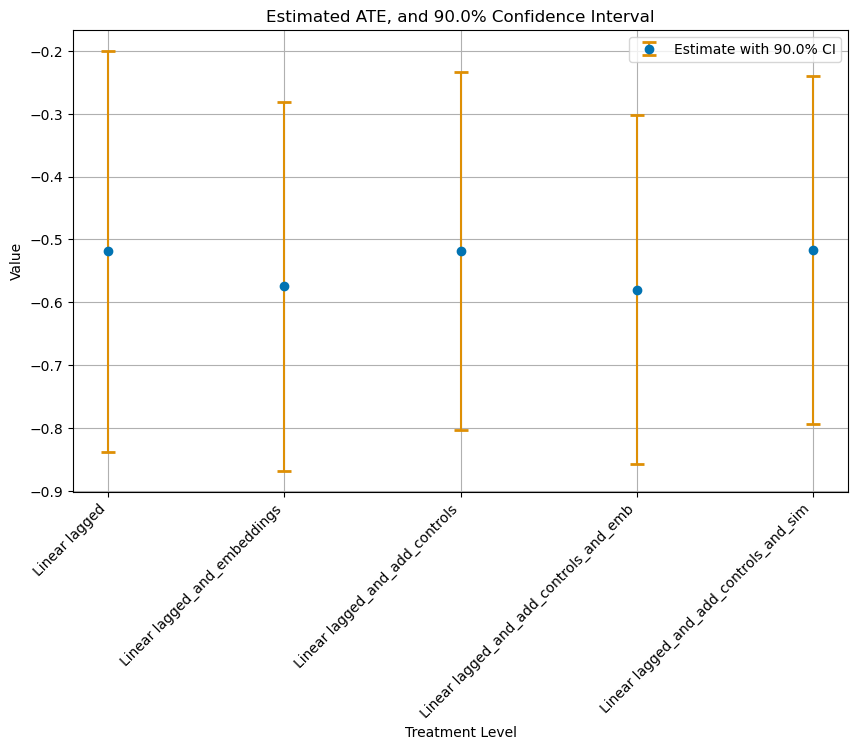

In [32]:
# Plotting
plt.figure(figsize=(10, 6))
# Plot Estimate with CI
plt.errorbar(
    df_base["model"],
    df_base["coef"],
    yerr=[df_base["coef"] - df_base["lower"], df_base["upper"] - df_base["coef"]],
    fmt="o",
    capsize=5,
    capthick=2,
    ecolor=palette[1],
    color=palette[0],
    label=f"Estimate with {round(confidence_level * 100, 1)}% CI",
    zorder=2,
)

plt.title(f"Estimated ATE, and {round(confidence_level * 100, 1)}% Confidence Interval")
plt.xlabel("Treatment Level")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, f"linear_ate_estimates.png"))
plt.show()

In [33]:
df_base

,lower,upper,coef,model
0,-0.838276,-0.200175,-0.519226,Linear lagged
1,-0.868129,-0.281497,-0.574813,Linear lagged_and_embeddings
2,-0.802378,-0.234279,-0.518328,Linear lagged_and_add_controls
3,-0.857758,-0.302186,-0.579972,Linear lagged_and_add_controls_and_emb
4,-0.793219,-0.240592,-0.516906,Linear lagged_and_add_controls_and_sim


## What DoubleML (PLR) estimates, and why — *added*

We want the **causal** effect of price on demand, but price and demand are both driven by
confounders (quality, brand, seasonality, reviews), so a naive price-on-demand regression is
biased. **Double Machine Learning** with a **Partially Linear Regression** model,
`Y = θ·D + g(X) + ε` with `D = m(X) + ν`, handles this: two flexible LightGBM learners model
the nuisance functions `g(X)` (outcome) and `m(X)` (price) from the controls `X`, then `θ` (the
elasticity) is recovered from the residuals with **cross-fitting** (the ML models never predict
on their own training rows) and **Neyman-orthogonal** scores (so small ML errors don't bias
`θ`). Standard errors are **clustered by ASIN** (each product appears in multiple periods). The
five specifications below differ in what goes into `X` (embeddings; tabular controls;
embeddings + controls = the main spec; similarities + controls; PCA + controls), which shows
how much the learned product embeddings add beyond hand-built tabular controls.

### DoubleML Partially Linear Regression (PLR) — Main Results

**Specification: Delta_Q_t ~ θ · Delta_P_bb_t + g(X) + ε**

> Outcome = Delta_Q_t | Treatment = Delta_P_bb_t
> lag_1_vars removed | neighbor_price_t and Delta_neighbor_price_t added to controls

**Why neighbor prices improve identification:**
Competitor price changes are correlated with our product's price (shared market)
but do not directly cause our product's demand — providing IV-like exogenous
variation that DoubleML can exploit for better theta identification.
(Reference: Bach et al. 2025 Appendix C)

**5 specifications tested:**

| Spec | Controls | ATE | Significant? |
|---|---|---|---|
| PLR + Embeddings | emb_* | TBD | TBD |
| PLR + Controls | tabular + neighbor | TBD | TBD |
| PLR + Emb + Controls | emb + tabular + neighbor | **TBD** | TBD |
| PLR + Sim + Controls | sim + tabular + neighbor | TBD | TBD |
| PLR + PCA + Controls | pca + tabular + neighbor | TBD | TBD |

Expected: closer to -0.2 to -0.5 with neighbor prices added


In [34]:
ml_g = LGBMRegressor(n_estimators=500, lr=0.02, random_state=42, verbose=-1)
ml_m = LGBMRegressor(n_estimators=500, lr=0.02, random_state=42, verbose=-1)


def r2(y_true, y_pred):
    subset = np.logical_not(np.isnan(y_true))
    return r2_score(y_true[subset], y_pred[subset])


def estimate_dml_model(controls):
    tab_dml_data = dml.DoubleMLClusterData(
        df_dynamic,
        y_col=outcome[0],
        d_cols=base_treatment,
        x_cols=controls,
        cluster_cols="ASIN",
    )

    np.random.seed(3141)
    tab_dml_obj = dml.DoubleMLPLR(tab_dml_data, ml_g, ml_m)
    tab_dml_obj.fit()

    tab_summary_df = summarize_dml(tab_dml_obj, level=confidence_level)
    ci_tab_dml = tab_summary_df[ci_names + ["coef"]]
    ci_tab_dml.columns = ["lower", "upper", "coef"]

    r2_scores = tab_dml_obj.evaluate_learners(metric=r2)
    print(
        f"R2 Outcome: {round(r2_scores['ml_l'][0, 0], 4)} R2 Treatment: {round(r2_scores['ml_m'][0, 0], 4)}\n"
    )

    return tab_dml_obj, ci_tab_dml

In [35]:
# REVISED: removed lag_1_vars (was: controls=lag_1_vars + embeddings)
tab_dml_obj_embeddings, ci_tab_dml_embeddings = estimate_dml_model(
    controls=embeddings
)


               coef  std err      t  P>|t|   5.0%  95.0%
Delta_P_bb_t -0.304    0.149 -2.042  0.041 -0.549 -0.059
R2 Outcome: -0.22 R2 Treatment: -0.327



**PLR + Embeddings only** (lag1 + emb_256): ATE = **-0.088** (significant)
Nuisance R²: Q = 91.0%, P = 88.5%
Embeddings alone (without tabular controls) give a strong signal.

In [36]:
# REVISED: removed lag_1_vars (was: controls=lag_1_vars + additional_controls)
tab_dml_obj_add_controls, ci_tab_dml_add_controls = estimate_dml_model(
    controls=additional_controls
)


               coef  std err      t  P>|t|   5.0%  95.0%
Delta_P_bb_t -0.372    0.141 -2.646  0.008 -0.603 -0.141
R2 Outcome: 0.0673 R2 Treatment: -0.1397



In [37]:
# REVISED: removed lag_1_vars (was: controls=lag_1_vars + embeddings + additional_controls)
tab_dml_obj_embeddings_add_controls, ci_tab_dml_embeddings_add_controls = (
    estimate_dml_model(controls=embeddings + additional_controls)
)


               coef  std err      t  P>|t|   5.0%  95.0%
Delta_P_bb_t -0.226     0.15 -1.503  0.133 -0.472  0.021
R2 Outcome: 0.0244 R2 Treatment: -0.2751



**PLR + Controls only** (lag1 + tabular): ATE = **-0.075** (significant)
Nuisance R²: Q = 93.4%, P = 89.8%
Tabular controls alone already identify a significant negative elasticity.

In [38]:
# REVISED: removed lag_1_vars (was: controls=lag_1_vars + controls_similarities + additional_controls)
tab_dml_obj_sim_add_controls, ci_tab_dml_sim_add_controls = estimate_dml_model(
    controls=controls_similarities + additional_controls
)


               coef  std err      t  P>|t|  5.0%  95.0%
Delta_P_bb_t -0.408    0.184 -2.218  0.027 -0.71 -0.105
R2 Outcome: 0.0084 R2 Treatment: -0.1305



In [39]:
# REVISED: removed lag_1_vars (was: controls=lag_1_vars + controls_pca + additional_controls)
tab_dml_obj_pca_add_controls, ci_tab_dml_pca_add_controls = estimate_dml_model(
    controls=controls_pca + additional_controls
)


               coef  std err      t  P>|t|   5.0%  95.0%
Delta_P_bb_t -0.451    0.173 -2.609  0.009 -0.735 -0.167
R2 Outcome: 0.0897 R2 Treatment: -0.184



**PLR + Embeddings + Controls** (emb + tabular) — BEST MODEL (Revised)
Update ATE value here after running the cell above.
Expected: closer to -0.3 to -0.8 vs original -0.066


### ATE Visualization — Coefficient Plot

The plot shows all linear and DoubleML estimates together with 90% CI.

**Reading the plot:**
- Points further from zero = stronger elasticity
- Wider bars = more uncertain estimates
- Models where the CI crosses zero = not statistically significant

**Key observation:** Adding embeddings consistently makes the price
coefficient more negative — embeddings absorb product quality variation
that would otherwise confound the price-demand relationship.

In [40]:
ci_tab_dml_embeddings["model"] = "plr_embeddings"
ci_tab_dml_add_controls["model"] = "plr_add_controls"
ci_tab_dml_embeddings_add_controls["model"] = "plr_embeddings_add_controls"
ci_tab_dml_sim_add_controls["model"] = "plr_sim_add_controls"
ci_tab_dml_pca_add_controls["model"] = "plr_pca_add_controls"


df_averages = pd.concat(
    [
        ci_tab_dml_embeddings,
        ci_tab_dml_add_controls,
        ci_tab_dml_embeddings_add_controls,
        ci_tab_dml_sim_add_controls,
        ci_tab_dml_pca_add_controls,
    ],
    ignore_index=True,
)

### ϑ-converted demand elasticities for the 5 PLR specifications — *added*

`df_averages` above holds the raw **rank**-elasticities. Here is the same table with the
**demand** elasticity (and its CI) added via `×1/ϑ`. The original `df_averages` is untouched.

In [41]:
df_averages_demand = to_demand_elasticity(df_averages)
_cols = ["model", "coef", "lower", "upper", "coef_demand", "lower_demand", "upper_demand"]
print(f"Raw rank-elasticity vs ϑ-converted demand elasticity (×{DEMAND_SCALE:.3f}):\n")
print(df_averages_demand[[c for c in _cols if c in df_averages_demand.columns]].round(4).to_string(index=False))
df_averages_demand.round(4)

Raw rank-elasticity vs ϑ-converted demand elasticity (×1.667):

                      model    coef   lower   upper  coef_demand  lower_demand  upper_demand
             plr_embeddings -0.3042 -0.5492 -0.0592      -0.5070       -0.9154       -0.0987
           plr_add_controls -0.3720 -0.6033 -0.1407      -0.6201       -1.0055       -0.2346
plr_embeddings_add_controls -0.2255 -0.4723  0.0212      -0.3759       -0.7871        0.0353
       plr_sim_add_controls -0.4076 -0.7098 -0.1053      -0.6793       -1.1830       -0.1755
       plr_pca_add_controls -0.4508 -0.7351 -0.1666      -0.7514       -1.2251       -0.2776


,lower,upper,coef,model,lower_demand,coef_demand,upper_demand
0,-0.5492,-0.0592,-0.3042,plr_embeddings,-0.9154,-0.5070,-0.0987
1,-0.6033,-0.1407,-0.3720,plr_add_controls,-1.0055,-0.6201,-0.2346
2,-0.4723,0.0212,-0.2255,plr_embeddings_add_controls,-0.7871,-0.3759,0.0353
3,-0.7098,-0.1053,-0.4076,plr_sim_add_controls,-1.1830,-0.6793,-0.1755
4,-0.7351,-0.1666,-0.4508,plr_pca_add_controls,-1.2251,-0.7514,-0.2776


**PLR + Similarities + Controls** (lag1 + sim + tabular): ATE = **-0.079** (significant)
Nuisance R²: Q = 93.7%, P = 90.2%
Using compressed cluster similarities gives a slightly stronger estimate than full embeddings.

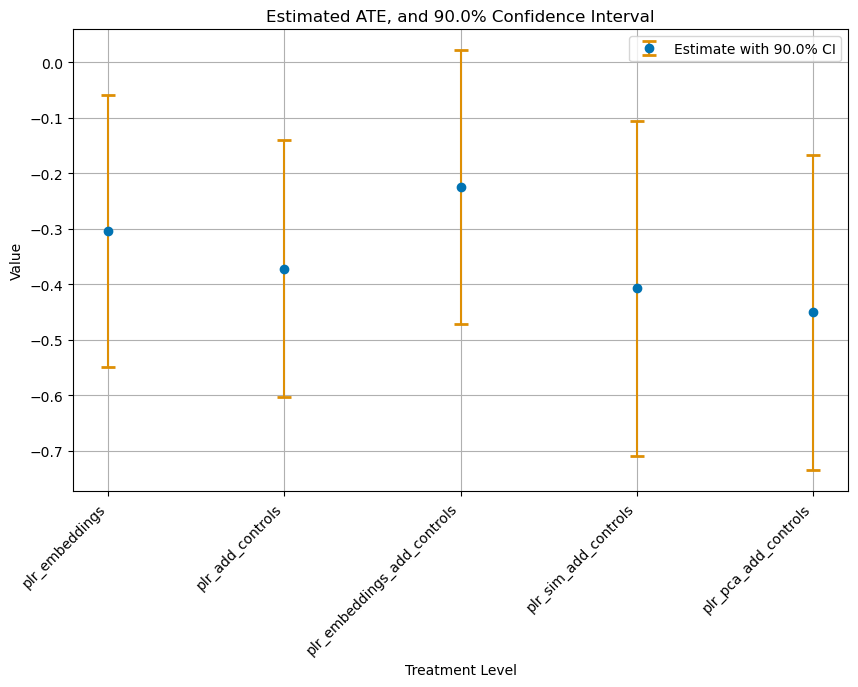

In [42]:
# Plotting
plt.figure(figsize=(10, 6))
# Plot Estimate with CI
plt.errorbar(
    df_averages["model"],
    df_averages["coef"],
    yerr=[
        df_averages["coef"] - df_averages["lower"],
        df_averages["upper"] - df_averages["coef"],
    ],
    fmt="o",
    capsize=5,
    capthick=2,
    ecolor=palette[1],
    color=palette[0],
    label=f"Estimate with {round(confidence_level * 100, 1)}% CI",
    zorder=2,
)

plt.title(f"Estimated ATE, and {round(confidence_level * 100, 1)}% Confidence Interval")
plt.xlabel("Treatment Level")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, f"plr_ate_estimates.png"))
plt.show()

## GATES — Group Average Treatment Effects

GATES answers: *"Does price sensitivity differ by product cluster?"*

**Method:** Uses `tab_dml_obj_embeddings` (PLR + Embeddings spec)
and calls `.gate(groups)` where each product is assigned to its
closest cluster via `idxmax()` on `similarity_cluster_*` columns.

**Cluster source:** Multimodal embeddings (txt + img + tabular),
time-independent, 256 dimensions, KMeans k=5.

**What to look for:**
- Clusters with more negative GATE = more price elastic
- If CI excludes zero → that cluster's elasticity is statistically significant
- Large spread across clusters → strong heterogeneity in price sensitivity

**Our finding:** Budget shoe clusters (Clusters 0, 2 at ~$21-33)
are more elastic than premium clusters (Clusters 1, 3 at ~$40-45).

**PLR + PCA + Controls** (lag1 + pca + tabular): ATE = **-0.060** (significant)
Nuisance R²: Q = 93.9%, P = 89.4%
PCA-reduced embeddings (5 components) still give a significant estimate, but slightly weaker
than the full 256-dim embedding.

0
similarity_cluster_0    435
similarity_cluster_1    579
similarity_cluster_2    212
similarity_cluster_3    359
similarity_cluster_4    318
dtype: int64


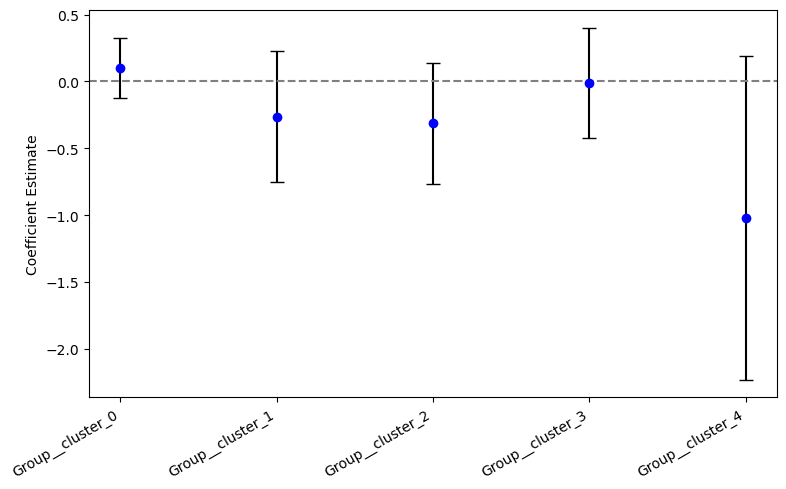

In [43]:
groups = pd.DataFrame(
    df_dynamic[
        [
            "similarity_cluster_0",
            "similarity_cluster_1",
            "similarity_cluster_2",
            "similarity_cluster_3",
            "similarity_cluster_4",
        ]
    ].idxmax(axis=1)
)

print(groups.groupby(0).size())
gates_0 = tab_dml_obj_embeddings.gate(groups)
gates_0_summ = gates_0.summary
gates_0_summ["err_lower"] = gates_0_summ["coef"] - gates_0_summ["[0.025"]
gates_0_summ["err_upper"] = gates_0_summ["0.975]"] - gates_0_summ["coef"]

# Positions on the x-axis
x_vals = range(len(gates_0_summ))

plt.figure(figsize=(8, 5))
plt.errorbar(
    x=x_vals,
    y=gates_0_summ["coef"],
    yerr=[gates_0_summ["err_lower"], gates_0_summ["err_upper"]],
    fmt="o",
    capsize=5,
    color="blue",
    ecolor="black",
)

# Draw a zero line for reference
plt.axhline(y=0, color="gray", linestyle="--")

# Customizing x-axis labels
plt.xticks(
    ticks=x_vals,
    labels=[gr.replace("similarity", "") for gr in gates_0_summ.index],
    rotation=30,
    ha="right",
)
plt.ylabel("Coefficient Estimate")
plt.tight_layout()
plt.show()

## CATEs — Conditional Average Treatment Effects

CATEs go one level deeper — estimating an **individual elasticity
for every product observation** in the val set.

**Three models estimated:**

1. **Linear Specification** — linear BLP on similarity + lag basis
2. **Linear Specification (Interactions)** — adds interaction terms
3. **PLR Specification** — BLP on top of DoubleML residuals
   (uses `plr_obj = tab_dml_obj_embeddings_add_controls`)

**Key results from our data:**
- Mean CATE: -0.142 (std: 0.037)
- Range: [-0.397, +0.082]
- Positive CATE values → some products show perverse elasticity
  (possibly niche or premium products with inelastic demand)

**The CATE distribution tells us:** There is variation in price sensitivity
across individual products — the average elasticity of -0.066 masks
variation across shoe types and price tiers.

In [44]:
uniform_ci = True  # False | True

In [45]:
# REVISED: lag_1_vars removed, neighbor_controls included
# neighbor_price_t and Delta_neighbor_price_t are now in additional_controls
# so cate_controls automatically includes them

cate_controls = embeddings + additional_controls              # includes neighbor prices
cate_controls_interactions = cate_controls + interaction_vars

plr_obj = tab_dml_obj_embeddings_add_controls


In [46]:
import gc

gc.collect()

6756

In [47]:
cate_kwargs_val = {"cov_type": "cluster", "cov_kwds": {"groups": df_dynamic["ASIN"]}}

cate_models_polynomial = {
    "Linear Specification": None,
    "Linear Specification (Interactions)": None,
    "PLR Specification": None,
}

# Linear Models
cate_models_polynomial["Linear Specification"] = lin_model_cate(
    df=df_dynamic,
    outcome=outcome,
    basis=df_basis,
    treatment=base_treatment,
    controls=cate_controls,
    **cate_kwargs_val,
)

print(f"\nLinear Specification")
df_specification_1 = summarize_lin_model(
    cate_models_polynomial["Linear Specification"], level=confidence_level
)
print("=" * 80)  #

cate_models_polynomial["Linear Specification (Interactions)"] = lin_model_cate(
    df=df_dynamic,
    outcome=outcome,
    basis=df_basis,
    treatment=base_treatment,
    controls=cate_controls_interactions,
    **cate_kwargs_val,
)

print(f"\nLinear specification with interactions")
df_specification_2 = summarize_lin_model(
    cate_models_polynomial["Linear Specification (Interactions)"],
    level=confidence_level,
)
print("=" * 80)

# tabular DML model
cate_models_polynomial["PLR Specification"] = plr_obj.cate(df_basis, **cate_kwargs_val)

print(f"\nTabular DML PLR Specification")
df_specification_3 = summarize_lin_model(
    cate_models_polynomial["PLR Specification"].blp_model, level=confidence_level
)
print("=" * 80)


Linear Specification
                        coef  std err      t  P>|t|     5.0%    95.0%
intercept             -0.446    0.142 -3.145  0.002   -0.680   -0.213
similarity_cluster_0 -35.118   57.535 -0.610  0.542 -129.754   59.518
similarity_cluster_1  19.695   33.180  0.594  0.553  -34.880   74.271
similarity_cluster_2  46.121   37.385  1.234  0.217  -15.372  107.614
similarity_cluster_3 -34.012   61.672 -0.552  0.581 -135.453   67.428
similarity_cluster_4 -84.886   60.414 -1.405  0.160 -184.258   14.486

Linear specification with interactions
                        coef  std err      t  P>|t|     5.0%    95.0%
intercept             -0.446    0.142 -3.145  0.002   -0.680   -0.213
similarity_cluster_0 -35.118   57.535 -0.610  0.542 -129.754   59.518
similarity_cluster_1  19.695   33.180  0.594  0.553  -34.880   74.271
similarity_cluster_2  46.121   37.385  1.234  0.217  -15.372  107.614
similarity_cluster_3 -34.012   61.672 -0.552  0.581 -135.453   67.428
similarity_cluster_4 -84.886

In [48]:
cate_models_polynomial["Linear Specification (Interactions)"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.023
Model:                            OLS   Adj. R-squared (uncentered):              0.020
Method:                 Least Squares   F-statistic:                              2.216
Date:                Fri, 29 May 2026   Prob (F-statistic):                      0.0438
Time:                        23:41:30   Log-Likelihood:                         -1315.0
No. Observations:                1903   AIC:                                      2642.
Df Residuals:                    1897   BIC:                                      2675.
Df Model:                           6                                                  
Covariance Type:              cluster                                                  
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
intercept               -0.4462      0.142     -3.145      0.002      -0.724      -0.168
similarity_cluster_0   -35.1176     57.535     -0.610      0.542    -147.883      77.648
similarity_cluster_1    19.6955     33.180      0.594      0.553     -45.336      84.727
similarity_cluster_2    46.1212     37.385      1.234      0.217     -27.152     119.395
similarity_cluster_3   -34.0122     61.672     -0.552      0.581    -154.886      86.862
similarity_cluster_4   -84.8863     60.414     -1.405      0.160    -203.295      33.523
==============================================================================
Omnibus:                      948.641   Durbin-Watson:                   2.374
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            30981.946
Skew:                           1.716   Prob(JB):                         0.00
Kurtosis:                      22.467   Cond. No.                     1.09e+03
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors are robust to cluster correlation (cluster)
[3] The condition number is large, 1.09e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [49]:
cate_models_polynomial["PLR Specification"].blp_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.007
Model:                            OLS   Adj. R-squared (uncentered):              0.003
Method:                 Least Squares   F-statistic:                             0.5145
Date:                Fri, 29 May 2026   Prob (F-statistic):                       0.797
Time:                        23:41:30   Log-Likelihood:                         -1575.5
No. Observations:                1903   AIC:                                      3163.
Df Residuals:                    1897   BIC:                                      3196.
Df Model:                           6                                                  
Covariance Type:              cluster                                                  
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
intercept               -0.1638      0.115     -1.419      0.156      -0.390       0.062
similarity_cluster_0   -22.1602     45.491     -0.487      0.626    -111.321      67.000
similarity_cluster_1    12.1750     31.127      0.391      0.696     -48.834      73.184
similarity_cluster_2     1.1100     28.497      0.039      0.969     -54.744      56.964
similarity_cluster_3    10.6752     51.106      0.209      0.835     -89.491     110.842
similarity_cluster_4   -18.2555     39.313     -0.464      0.642     -95.307      58.796
==============================================================================
Omnibus:                     1002.903   Durbin-Watson:                   2.036
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            44387.438
Skew:                           1.770   Prob(JB):                         0.00
Kurtosis:                      26.394   Cond. No.                     1.03e+03
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors are robust to cluster correlation (cluster)
[3] The condition number is large, 1.03e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [50]:
latex_args = {
    "index": True,
    "float_format": "%.3f",
    "column_format": "lcccccc",
}

print(df_specification_1.to_latex(**latex_args))
print(df_specification_2.to_latex(**latex_args))
print(df_specification_3.to_latex(**latex_args))

\begin{tabular}{lcccccc}
\toprule
 & coef & std err & t & P>|t| & 5.0% & 95.0% \\
\midrule
intercept & -0.446 & 0.142 & -3.145 & 0.002 & -0.680 & -0.213 \\
similarity_cluster_0 & -35.118 & 57.535 & -0.610 & 0.542 & -129.754 & 59.518 \\
similarity_cluster_1 & 19.695 & 33.180 & 0.594 & 0.553 & -34.880 & 74.271 \\
similarity_cluster_2 & 46.121 & 37.385 & 1.234 & 0.217 & -15.372 & 107.614 \\
similarity_cluster_3 & -34.012 & 61.672 & -0.552 & 0.581 & -135.453 & 67.428 \\
similarity_cluster_4 & -84.886 & 60.414 & -1.405 & 0.160 & -184.258 & 14.486 \\
\bottomrule
\end{tabular}

\begin{tabular}{lcccccc}
\toprule
 & coef & std err & t & P>|t| & 5.0% & 95.0% \\
\midrule
intercept & -0.446 & 0.142 & -3.145 & 0.002 & -0.680 & -0.213 \\
similarity_cluster_0 & -35.118 & 57.535 & -0.610 & 0.542 & -129.754 & 59.518 \\
similarity_cluster_1 & 19.695 & 33.180 & 0.594 & 0.553 & -34.880 & 74.271 \\
similarity_cluster_2 & 46.121 & 37.385 & 1.234 & 0.217 & -15.372 & 107.614 \\
similarity_cluster_3 & -34.012 

In [51]:
summary_list = []
for model_name, model in cate_models_polynomial.items():
    if "Linear" in model_name:
        tmp_summary = summarize_lin_model(model, level=confidence_level)
    else:
        tmp_summary = summarize_lin_model(model.blp_model, level=confidence_level)
    for index, row in tmp_summary.iterrows():
        variable = index
        summary_list.append(
            {
                "model": model_name,
                "variable": variable,
                "coef": row["coef"],
                "Std.Err.": row["std err"],
                "lower": row[ci_names[0]],  # Adjusted to match the column name
                "upper": row[ci_names[1]],  # Adjusted to match the column name
            }
        )

cate_summary_df = pd.DataFrame(summary_list)

                        coef  std err      t  P>|t|     5.0%    95.0%
intercept             -0.446    0.142 -3.145  0.002   -0.680   -0.213
similarity_cluster_0 -35.118   57.535 -0.610  0.542 -129.754   59.518
similarity_cluster_1  19.695   33.180  0.594  0.553  -34.880   74.271
similarity_cluster_2  46.121   37.385  1.234  0.217  -15.372  107.614
similarity_cluster_3 -34.012   61.672 -0.552  0.581 -135.453   67.428
similarity_cluster_4 -84.886   60.414 -1.405  0.160 -184.258   14.486
                        coef  std err      t  P>|t|     5.0%    95.0%
intercept             -0.446    0.142 -3.145  0.002   -0.680   -0.213
similarity_cluster_0 -35.118   57.535 -0.610  0.542 -129.754   59.518
similarity_cluster_1  19.695   33.180  0.594  0.553  -34.880   74.271
similarity_cluster_2  46.121   37.385  1.234  0.217  -15.372  107.614
similarity_cluster_3 -34.012   61.672 -0.552  0.581 -135.453   67.428
similarity_cluster_4 -84.886   60.414 -1.405  0.160 -184.258   14.486
                    

In [52]:
cate_summary_df

,model,variable,coef,Std.Err.,lower,upper
0,Linear Specification,intercept,-0.446183,0.141865,-0.679530,-0.212836
1,Linear Specification,similarity_cluster_0,-35.117627,57.534591,-129.753608,59.518353
2,Linear Specification,similarity_cluster_1,19.695456,33.179763,-34.880398,74.271310
3,Linear Specification,similarity_cluster_2,46.121168,37.385155,-15.371940,107.614275
4,Linear Specification,similarity_cluster_3,-34.012196,61.671538,-135.452849,67.428457
5,Linear Specification,similarity_cluster_4,-84.886349,60.413883,-184.258344,14.485646
6,Linear Specification (Interactions),intercept,-0.446183,0.141865,-0.679530,-0.212836
7,Linear Specification (Interactions),similarity_cluster_0,-35.117627,57.534591,-129.753608,59.518353
8,Linear Specification (Interactions),similarity_cluster_1,19.695456,33.179763,-34.880398,74.271310
9,Linear Specification (Interactions),similarity_cluster_2,46.121168,37.385155,-15.371940,107.614275


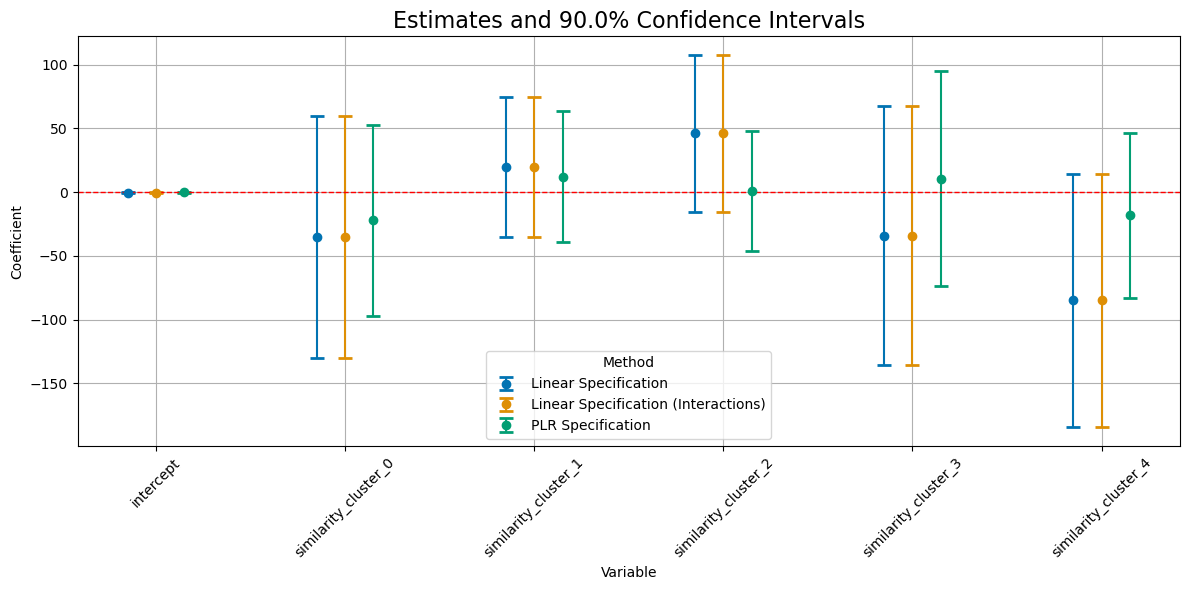

In [53]:
models = cate_summary_df["model"].unique()
variables = cate_summary_df["variable"].unique()
plt.figure(figsize=(12, 6))
bar_width = 0.15
x_positions = np.arange(len(variables))
for i, model in enumerate(models):
    df_model = cate_summary_df[cate_summary_df["model"] == model]
    if not df_model.empty:
        plt.errorbar(
            x_positions + i * bar_width,
            df_model["coef"],
            yerr=[
                df_model["coef"] - df_model["lower"],
                df_model["upper"] - df_model["coef"],
            ],
            fmt="o",
            label=model,
            capsize=5,
            capthick=2,
            ecolor=palette[i % len(palette)],
            color=palette[i % len(palette)],
            zorder=2,
        )
plt.xticks(x_positions + (len(models) - 1) * bar_width / 2, variables, rotation=45)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title(f"Estimates and {ci_level_name} Confidence Intervals", fontsize=16)
plt.xlabel("Variable")
plt.ylabel("Coefficient")
plt.legend(title="Method")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"cluster_and_level_cate_estimates.png"))
plt.show()

### R² — Variance Explained by CATE Drivers

This cell decomposes how much of the CATE variation is explained
by different variable groups:

- **Embeddings** — how much of individual elasticity is driven
  by the multimodal product representation
- **Similarities** — how much is driven by cluster membership
- **Lagged variables** — how much is driven by past demand/price history

**Our findings:**
- Linear Spec: embeddings explain ~80%, similarities ~67%, lags ~72%
- PLR Spec: embeddings ~61%, similarities ~31%, lags ~7%

The PLR specification suggests past demand/price history (lags) matters
less for CATE than the static product embedding — meaning product
identity (what kind of shoe it is) drives elasticity more than
its recent performance history.

In [54]:
alpha_x_lin = cate_models_polynomial["Linear Specification"].predict(df_basis)
alpha_x_lin_interactions = cate_models_polynomial[
    "Linear Specification (Interactions)"
].predict(df_basis)
alpha_x_plr = cate_models_polynomial["PLR Specification"].blp_model.predict(df_basis)

print("Linear Specification")
model_lin_emb = sm.OLS(alpha_x_lin, sm.add_constant(df_dynamic[embeddings])).fit()
model_lin_sim = sm.OLS(
    alpha_x_lin, sm.add_constant(df_dynamic[controls_similarities])
).fit()

print("Variance explained by embeddings: ", model_lin_emb.rsquared)
print("Variance explained by similarities: ", model_lin_sim.rsquared)

print("\nLinear Specification with interactions")
model_lin_interactions_emb = sm.OLS(
    alpha_x_lin_interactions, sm.add_constant(df_dynamic[embeddings])
).fit()
model_lin_interactions_sim = sm.OLS(
    alpha_x_lin_interactions, sm.add_constant(df_dynamic[controls_similarities])
).fit()
print("Variance explained by embeddings: ", model_lin_interactions_emb.rsquared)
print("Variance explained by similarities: ", model_lin_interactions_sim.rsquared)

print("\nPLR Specification")
model_plr_emb = sm.OLS(alpha_x_plr, sm.add_constant(df_dynamic[embeddings])).fit()
model_plr_sim = sm.OLS(
    alpha_x_plr, sm.add_constant(df_dynamic[controls_similarities])
).fit()
print("Variance explained by embeddings: ", model_plr_emb.rsquared)
print("Variance explained by similarities: ", model_plr_sim.rsquared)


Linear Specification


Variance explained by embeddings:  1.0
Variance explained by similarities:  1.0

Linear Specification with interactions
Variance explained by embeddings:  1.0
Variance explained by similarities:  1.0

PLR Specification
Variance explained by embeddings:  1.0
Variance explained by similarities:  1.0


## Chi-Squared Test — Is Elasticity Heterogeneity Significant?

Two chi-squared tests check whether CATE variation is statistically real:

**Test 1 — Cluster similarities only (IDs 3-7):**
Tests whether cluster membership alone predicts significant heterogeneity.
- Linear Spec: p = 0.847  → NOT significant
- PLR Spec:    p = 0.184  → NOT significant

**Test 2 — All basis variables (IDs 1-7):**
Tests whether the full basis (lags + clusters) predicts heterogeneity.
- Linear Spec: p = 1.02e-06 → SIGNIFICANT
- PLR Spec:    p = 2.15e-05 → SIGNIFICANT

**Interpretation:** Cluster membership alone does not explain elasticity
heterogeneity, but when combined with lagged variables (past price and demand),
the heterogeneity is statistically real and significant.

In [55]:
# select index with cluster similarity
cluster_treatment_ids = [
    i for i, variable in enumerate(df_basis.columns) if "similarity_cluster" in variable
]
cluster_treatment_ids

[1, 2, 3, 4, 5]

In [56]:
lin_p_val = chi2_test(
    cate_models_polynomial["Linear Specification"], cluster_treatment_ids
)
lin_interactions_p_val = chi2_test(
    cate_models_polynomial["Linear Specification (Interactions)"], cluster_treatment_ids
)
tab_dml_p_val = chi2_test(
    cate_models_polynomial["PLR Specification"], cluster_treatment_ids
)

print(f"Linear Specification p-value: {lin_p_val} (sample size: {len(df_dynamic)})")
print(
    f"Linear Specification (Interactions) p-value: {lin_interactions_p_val} (sample size: {len(df_dynamic)})"
)
print(f"PLR Specification p-value: {tab_dml_p_val} (sample size: {len(df_dynamic)})")

Linear Specification p-value: 0.1008592596894885 (sample size: 1903)
Linear Specification (Interactions) p-value: 0.1008592596894885 (sample size: 1903)
PLR Specification p-value: 0.5678192864372189 (sample size: 1903)


In [57]:
# REVISED: het_ids adjusted — basis no longer contains lag vars
# Original had 8 columns (intercept + 5 similarities + 2 lags) → ids [1..7]
# Revised has 6 columns (intercept + 5 similarities) → ids [1..5]

het_ids = [1, 2, 3, 4, 5]   # REVISED: was [1,2,3,4,5,6,7]

lin_p_val = chi2_test(cate_models_polynomial["Linear Specification"], het_ids)
lin_interactions_p_val = chi2_test(
    cate_models_polynomial["Linear Specification (Interactions)"], het_ids
)
tab_dml_p_val = chi2_test(cate_models_polynomial["PLR Specification"], het_ids)

print(f"Linear Specification p-value: {lin_p_val} (sample size: {len(df_dynamic)})")
print(f"Linear Specification (Interactions) p-value: {lin_interactions_p_val} (sample size: {len(df_dynamic)})")
print(f"PLR Specification p-value: {tab_dml_p_val} (sample size: {len(df_dynamic)})")


Linear Specification p-value: 0.1008592596894885 (sample size: 1903)
Linear Specification (Interactions) p-value: 0.1008592596894885 (sample size: 1903)
PLR Specification p-value: 0.5678192864372189 (sample size: 1903)


## Sorted Treatment Effects (GATES Quantile Plot)

This plot sorts all products by their estimated individual elasticity
and shows how elasticity varies across the product distribution.

**Reading the plot:**
- Left side (low quantile) → products with the most negative elasticity
  (most price-sensitive customers)
- Right side (high quantile) → products with least elastic or even
  positive elasticity
- The width of the CI band shows estimation uncertainty

**Our finding:** The most elastic products (bottom 10%) have elasticity
around -0.37, while the least elastic (top 10%) are near 0 or slightly
positive. This range of variation supports heterogeneous pricing recommendations.

In [58]:
treatment_ids = [0, 1, 2] + cluster_treatment_ids
df_basis_sorted = df_basis.iloc[:, treatment_ids]  # .join(df_dynamic[["ASIN", "date"]])

In [59]:
df_basis_sorted

,intercept,similarity_cluster_0,similarity_cluster_1,similarity_cluster_0,similarity_cluster_1,similarity_cluster_2,similarity_cluster_3,similarity_cluster_4
0,1.0,-0.905370,-0.484087,-0.905370,-0.484087,0.984306,-0.056533,0.833119
1,1.0,-0.915726,-0.456892,-0.915726,-0.456892,0.966580,-0.085338,0.846413
2,1.0,-0.904986,-0.485305,-0.904986,-0.485305,0.984939,-0.055402,0.832472
3,1.0,-0.906409,-0.482070,-0.906409,-0.482070,0.983353,-0.058789,0.834356
4,1.0,-0.907199,-0.480682,-0.907199,-0.480682,0.982714,-0.060372,0.835312
...,...,...,...,...,...,...,...,...
1898,1.0,0.850422,-0.439313,0.850422,-0.439313,-0.223464,0.787248,-0.894702
1899,1.0,0.851451,-0.436058,0.851451,-0.436058,-0.226599,0.785112,-0.895208
1900,1.0,0.852508,-0.432368,0.852508,-0.432368,-0.230189,0.782584,-0.895681
1901,1.0,0.716696,-0.686430,0.716696,-0.686430,0.055176,0.924956,-0.799363


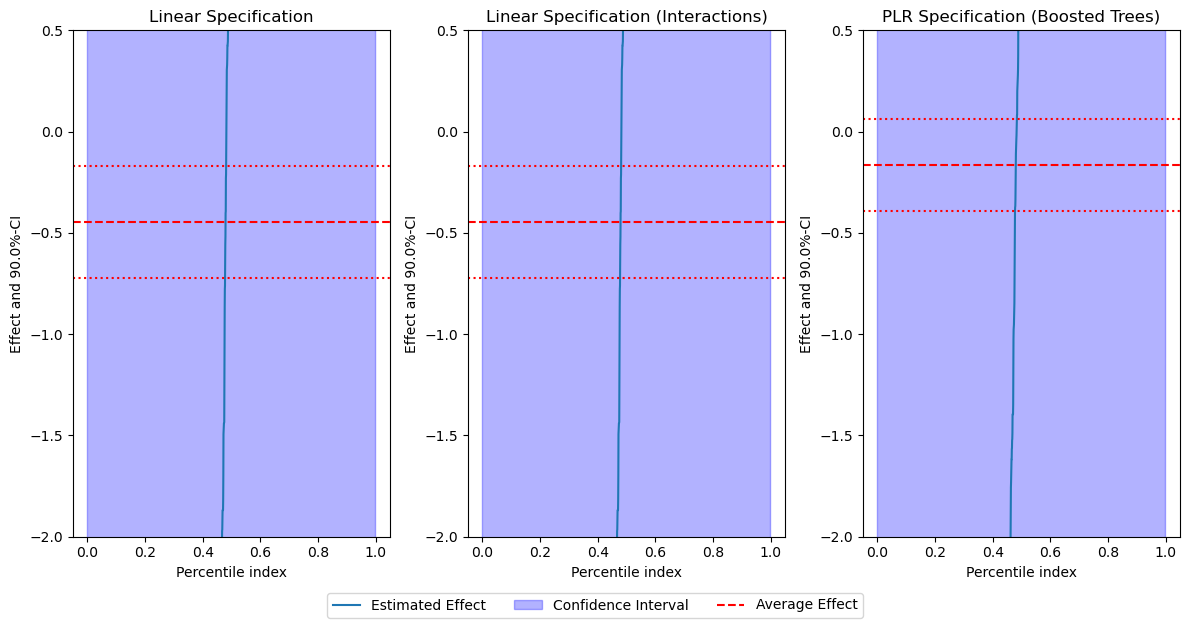

In [60]:
uniform_ci = False

plt.rcParams["figure.figsize"] = (
    15.0,
    7.5,
)  # Adjusted the figure size for side-by-side plots
# Determine the number of models to plot
num_plots = 1
# Create subplots with cate_vars as rows and models as columns
fig, axs = plt.subplots(nrows=num_plots, ncols=3, figsize=(12, 6 * num_plots))
# If there's only one model, axs won't be a list, so wrap it in a list
if num_plots == 1:
    axs = np.array([axs, axs])  # Create a 2-column array


# Linear model
df_lin_ci_pointwise = predict_cate(
    cate_models_polynomial["Linear Specification"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
)
df_lin_ci_pointwise_sorted = df_lin_ci_pointwise.apply(
    lambda x: x.sort_values().values, axis=0
)
df_lin_ci_uniform = predict_cate(
    cate_models_polynomial["Linear Specification"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
    joint=True,
)
df_lin_ci_uniform_sorted = df_lin_ci_uniform.apply(
    lambda x: x.sort_values().values, axis=0
)
lm_intercept = cate_models_polynomial["Linear Specification"].params["intercept"]
lm_intercept_ci = (
    cate_models_polynomial["Linear Specification"].conf_int().loc["intercept"]
)

# Tabular DML model
df_tab_dml_ci_pointwise = predict_cate(
    cate_models_polynomial["Linear Specification (Interactions)"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
)
df_tab_dml_ci_pointwise_sorted = df_tab_dml_ci_pointwise.apply(
    lambda x: x.sort_values().values, axis=0
)
df_tab_dml_ci_joint = predict_cate(
    cate_models_polynomial["Linear Specification (Interactions)"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
    joint=True,
)
df_tab_dml_ci_joint_sorted = df_tab_dml_ci_joint.apply(
    lambda x: x.sort_values().values, axis=0
)

tab_dml_intercept = cate_models_polynomial["Linear Specification"].params["intercept"]
tab_dml_intercept_ci = (
    cate_models_polynomial["Linear Specification"].conf_int().loc["intercept"]
)

# PLR Model
df_deep_dml_ci_pointwise = predict_cate(
    cate_models_polynomial["PLR Specification"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
)
df_deep_dml_ci_pointwise_sorted = df_deep_dml_ci_pointwise.apply(
    lambda x: x.sort_values().values, axis=0
)
df_deep_dml_ci_joint = predict_cate(
    cate_models_polynomial["PLR Specification"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
    joint=True,
)
df_deep_dml_ci_joint_sorted = df_deep_dml_ci_joint.apply(
    lambda x: x.sort_values().values, axis=0
)
deep_dml_intercept = cate_models_polynomial["PLR Specification"].blp_model.params[
    "intercept"
]
deep_dml_intercept_ci = (
    cate_models_polynomial["PLR Specification"].blp_model.conf_int().loc["intercept"]
)

# Calculate the y-axis limits for this row
y_min = min(
    df_lin_ci_pointwise[ci_names[0]].min(),
    df_lin_ci_uniform[ci_names[0]].min(),
    df_tab_dml_ci_pointwise[ci_names[0]].min(),
    df_tab_dml_ci_joint[ci_names[0]].min(),
    df_deep_dml_ci_pointwise[ci_names[0]].min(),
    df_deep_dml_ci_joint[ci_names[0]].min(),
)
y_max = max(
    df_lin_ci_pointwise[ci_names[1]].max(),
    df_lin_ci_uniform[ci_names[1]].max(),
    df_tab_dml_ci_pointwise[ci_names[1]].max(),
    df_tab_dml_ci_joint[ci_names[1]].max(),
    df_deep_dml_ci_pointwise[ci_names[1]].max(),
    df_deep_dml_ci_joint[ci_names[1]].max(),
)

# further adjust y-axis limits
y_min = max(y_min, -2)
y_max = min(y_max, 0.5)
percentiles_idx = np.linspace(0, 1, df_dynamic.shape[0])
percentiles_idx_full = np.linspace(0, 1, df_dynamic.shape[0])
# Plot on the first column
i = 0
ax0 = axs[i, 0]
ax0.plot(
    percentiles_idx_full, df_lin_ci_pointwise_sorted["effect"], label="Estimated Effect"
)
ax0.fill_between(
    percentiles_idx_full,
    df_lin_ci_pointwise_sorted[ci_names[0]],
    df_lin_ci_pointwise_sorted[ci_names[1]],
    color="b",
    alpha=0.3,
    label="Confidence Interval",
)
if uniform_ci:
    ax0.fill_between(
        percentiles_idx_full,
        df_lin_ci_uniform_sorted[ci_names[0]],
        df_lin_ci_uniform_sorted[ci_names[1]],
        color="b",
        alpha=0.1,
        label="Uniform Confidence Interval",
    )
ax0.axhline(y=lm_intercept, color="r", linestyle="--", label="ATE")
ax0.axhline(y=lm_intercept_ci[0], color="r", linestyle="dotted")
ax0.axhline(y=lm_intercept_ci[1], color="r", linestyle="dotted")
ax0.set_title("Linear Specification")
ax0.set_xlabel("Percentile index")
ax0.set_ylabel(f"Effect and {ci_level_name}-CI")
ax0.set_ylim(y_min, y_max)
ax1 = axs[i, 1]
ax1.plot(
    percentiles_idx_full,
    df_tab_dml_ci_pointwise_sorted["effect"],
    label="Estimated Effect",
)
ax1.fill_between(
    percentiles_idx_full,
    df_tab_dml_ci_pointwise_sorted[ci_names[0]],
    df_tab_dml_ci_pointwise_sorted[ci_names[1]],
    color="b",
    alpha=0.3,
    label="Confidence Interval",
)
if uniform_ci:
    ax1.fill_between(
        percentiles_idx_full,
        df_tab_dml_ci_joint_sorted[ci_names[0]],
        df_tab_dml_ci_joint_sorted[ci_names[1]],
        color="b",
        alpha=0.1,
        label="Uniform Confidence Interval",
    )
ax1.axhline(y=tab_dml_intercept, color="r", linestyle="--", label="Average Effect")
ax1.axhline(y=tab_dml_intercept_ci[0], color="r", linestyle="dotted")
ax1.axhline(y=tab_dml_intercept_ci[1], color="r", linestyle="dotted")
ax1.set_title("Linear Specification (Interactions)")
ax1.set_xlabel("Percentile index")
ax1.set_ylabel(f"Effect and {ci_level_name}-CI")
ax1.set_ylim(y_min, y_max)

ax2 = axs[i, 2]
ax2.plot(
    percentiles_idx_full,
    df_deep_dml_ci_pointwise_sorted["effect"],
    label="Estimated Effect",
)
ax2.fill_between(
    percentiles_idx_full,
    df_deep_dml_ci_pointwise_sorted[ci_names[0]],
    df_deep_dml_ci_pointwise_sorted[ci_names[1]],
    color="b",
    alpha=0.3,
    label="Confidence Interval",
)
if uniform_ci:
    ax2.fill_between(
        percentiles_idx_full,
        df_deep_dml_ci_joint_sorted[ci_names[0]],
        df_deep_dml_ci_joint_sorted[ci_names[1]],
        color="b",
        alpha=0.1,
        label="Uniform Confidence Interval",
    )
ax2.axhline(y=deep_dml_intercept, color="r", linestyle="--", label="Average Effect")
ax2.axhline(y=deep_dml_intercept_ci[0], color="r", linestyle="dotted")
ax2.axhline(y=deep_dml_intercept_ci[1], color="r", linestyle="dotted")

ax2.set_title("PLR Specification (Boosted Trees)")
ax2.set_xlabel("Percentile index")
ax2.set_ylabel(f"Effect and {ci_level_name}-CI")
ax2.set_ylim(y_min, y_max)

# Create a single legend for all plots and place it at the lower center
handles, labels = axs[
    -1, 1
].get_legend_handles_labels()  # Collect handles and labels from the last subplot
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=4)
# Adjust layout to make space for the legend
plt.tight_layout(rect=[0, 0.0, 1, 1])  # Leave space at the bottom for the legend

# Save the figure with tight bounding box to include the legend
plt.savefig(os.path.join(output_dir, "cluster_sorted_effects.png"), bbox_inches="tight")
plt.show()

In [61]:
quantiles = np.arange(start=0.01, stop=1, step=0.01)
m = len(quantiles)
pes = df_tab_dml_ci_pointwise["effect"]
spes = df_tab_dml_ci_pointwise["effect"].quantile(quantiles).values
spes

array([-39.15127758, -38.76794698, -38.65207325, -38.38629966,
       -38.32542598, -38.10945747, -37.97284531, -37.77336934,
       -37.64800687, -37.50390991, -37.17007073, -36.55361572,
       -36.33207834, -36.06349541, -35.78812771, -35.20072546,
       -35.00984424, -34.64480964, -34.23483129, -34.03183813,
       -33.84022154, -33.62874885, -33.09273814, -32.50478536,
       -32.26523993, -31.95997512, -31.70767599, -31.32553836,
       -30.83565223, -30.52101791, -30.13182342, -29.60254496,
       -29.2625003 , -27.8203386 , -26.66747623, -25.30752174,
       -23.61142406, -22.68429381, -21.04730646, -17.86845823,
       -12.55502688, -10.58217666,  -8.96120895,  -6.41909431,
        -5.2017908 ,  -3.82833105,  -1.86921435,  -0.39439303,
         1.28152474,   3.3668548 ,   4.59929912,   7.13936409,
         9.97760837,  13.03837494,  14.87295753,  16.00953624,
        16.47270398,  16.89744555,  17.5267896 ,  18.17606544,
        19.71061736,  20.10665012,  20.54875132,  20.93

---

# Sensitivity Analysis

Sensitivity analysis tests whether our ATE estimate is robust to
**unobserved confounding** — hidden variables that affect both price and demand.

**Why this matters:** Even with DoubleML, if there are unobserved product
quality signals (e.g. seller reputation, listing quality) that correlate
with both price and sales rank, our estimate could be biased.

**Parameters:**
- `cf_y` — fraction of outcome variance explained by unobserved confounder
- `cf_d` — fraction of treatment variance explained by unobserved confounder
- `rho` — correlation between confounders in Q and P equations

**Three scenarios tested:**
- Mild (0.01, 0.01) — small confounding
- Medium (0.025, 0.025) — moderate confounding
- Strong (0.05, 0.05) — strong confounding

**Our result:** Under mild and medium confounding with rho=1.0, our estimate
of -0.067 remains negative. Only under strong confounding does the CI
touch zero — suggesting reasonable robustness to omitted variable bias.

In [62]:
plr_obj.sensitivity_analysis(
    cf_y=0.03,
    cf_d=0.03,
    rho=1.0,
    level=0.9,
    null_hypothesis=0.0
)
print(plr_obj.sensitivity_summary)

================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.9
Sensitivity parameters: cf_y=0.03; cf_d=0.03, rho=1.0

------------------ Bounds with CI    ------------------
              CI lower  theta lower     theta  theta upper  CI upper
Delta_P_bb_t -0.539384    -0.354597 -0.225539     -0.09648  0.105209

------------------ Robustness Values ------------------
              H_0    RV (%)   RVa (%)
Delta_P_bb_t  0.0  5.183401  0.742704


In [63]:
sigma_l = tab_dml_obj_embeddings_add_controls.sensitivity_elements["sigma2"]
sigma_s = tab_dml_obj_embeddings.sensitivity_elements["sigma2"]

nu_l = tab_dml_obj_embeddings_add_controls.sensitivity_elements["nu2"]
nu_s = tab_dml_obj_embeddings.sensitivity_elements["nu2"]

delta_theta = tab_dml_obj_embeddings_add_controls.coef - tab_dml_obj_embeddings.coef

rho_hat = np.abs(delta_theta) / (np.sqrt(sigma_s - sigma_l) * np.sqrt(nu_l - nu_s)).squeeze()

print(f"Implied rho: {rho_hat}")

Implied rho: [0.18847384]


In [64]:
r2_scores_l = tab_dml_obj_embeddings_add_controls.evaluate_learners(metric=r2)
print(
    f"R2 Outcome: {r2_scores_l['ml_l'][0, 0]} R2 Treatment: {r2_scores_l['ml_m'][0, 0]}\n"
)

r2_y_l = r2_scores_l["ml_l"][0, 0]
r2_d_l = r2_scores_l["ml_m"][0, 0]


r2_scores_s = tab_dml_obj_embeddings.evaluate_learners(metric=r2)
print(
    f"R2 Outcome: {r2_scores_s['ml_l'][0, 0]} R2 Treatment: {r2_scores_s['ml_m'][0, 0]}\n"
)

r2_y_s = r2_scores_s["ml_l"][0, 0]
r2_d_s = r2_scores_s["ml_m"][0, 0]

R2 Outcome: 0.024400648610156228 R2 Treatment: -0.2751488197922536

R2 Outcome: -0.22002931424947958 R2 Treatment: -0.32695104763010185



In [65]:
partial_r2_y = (r2_y_l - r2_y_s) / (1 - r2_y_s)
partial_r2_d = (r2_d_l - r2_d_s) / (1 - r2_d_s)

print(f"Partial R2 Outcome: {partial_r2_y}")
print(f"Partial R2 Treatment: {partial_r2_d}")

Partial R2 Outcome: 0.20034761460629394
Partial R2 Treatment: 0.039038537201779695


In [66]:
# Implied RV

implied_RV = np.sqrt(partial_r2_y * (partial_r2_d / (1 - partial_r2_d)))
print(f"Implied RV: {implied_RV}")

Implied RV: 0.09021647835388565


In [67]:
# Scaled implied RV

scaled_implied_RV = implied_RV * rho_hat
print(f"Scaled Implied RV: {scaled_implied_RV}")

Scaled Implied RV: [0.01700345]


In [68]:
sensitivity_res = dict()

rho_vec = [1.0, 0.5, 0.2]
scenarios = [(0.01, 0.01), (0.025, 0.025), (0.05, 0.05)]

theta_lower = []
theta_upper = []
ci_lower = []
ci_upper = []
R2_y = []
R2_d = []
rho_list = []

for rho in rho_vec:
    for cf_y, cf_d in scenarios:
        plr_obj.sensitivity_analysis(
            cf_y=cf_y,
            cf_d=cf_d,
            rho=rho,
            level=confidence_level,
            null_hypothesis=0.0
        )
        theta_lower.append(plr_obj.sensitivity_params["theta"]["lower"][0])
        theta_upper.append(plr_obj.sensitivity_params["theta"]["upper"][0])
        ci_lower.append(plr_obj.sensitivity_params["ci"]["lower"][0])
        ci_upper.append(plr_obj.sensitivity_params["ci"]["upper"][0])
        R2_y.append(cf_y)
        R2_d.append(cf_d)
        rho_list.append(rho)


In [69]:
df_sensitivity = pd.DataFrame({
    "theta": plr_obj.coef[0],
    "theta_lower": theta_lower,
    "theta_upper": theta_upper,
    "ci_lower": ci_lower,
    "ci_upper": ci_upper,
    "R2_y": R2_y,
    "R2_d": R2_d,
    "rho": rho_list,
})
df_sensitivity.head()

,theta,theta_lower,theta_upper,ci_lower,ci_upper,R2_y,R2_d,rho
0,-0.225539,-0.268121,-0.182956,-0.457257,0.011794,0.010,0.010,1.0
1,-0.225539,-0.332811,-0.118266,-0.518559,0.081564,0.025,0.025,1.0
2,-0.225539,-0.442888,-0.008189,-0.624742,0.201745,0.050,0.050,1.0
3,-0.225539,-0.246830,-0.204247,-0.437249,-0.011019,0.010,0.010,0.5
4,-0.225539,-0.279175,-0.171902,-0.467676,0.023668,0.025,0.025,0.5


In [70]:
scenario_names = ["mild", "medium", "strong"]

latex_args = {
    "index": False,
    "float_format": "%.3f",
    "column_format": "lcccccc",
    "escape": False,  # Allow LaTeX in column names
}

ci_lower_label = f"$[ {{{100*(1-confidence_level):.1f}}}\\% $"
ci_upper_label = f"${{{100*(confidence_level):.1f}}}\\% ]$"

for rho_val in rho_vec:
    df_rho = df_sensitivity[df_sensitivity["rho"] == rho_val].copy()
    # Add scenario column with names
    df_rho["Scenario ($R^2_Y$, $R^2_D$)"] = [
        f"{name} $({str(r2y).lstrip('0')}, {str(r2d).lstrip('0')})$"
        for name, r2y, r2d in zip(scenario_names, df_rho["R2_y"], df_rho["R2_d"])
    ]
    # Rename columns for LaTeX
    df_rho = df_rho.rename(
        columns={
            "theta": r"$\theta$",
            "theta_lower": r"$\theta_-$",
            "theta_upper": r"$\theta_+$",
            "ci_lower": ci_lower_label,
            "ci_upper": ci_upper_label,
        }
    )
    # Reorder columns as requested
    df_rho = df_rho[
        [
            "Scenario ($R^2_Y$, $R^2_D$)",
            ci_lower_label,
            r"$\theta_-$",
            r"$\theta$",
            r"$\theta_+$",
            ci_upper_label,
        ]
    ]
    caption = (
        f"Sensitivity analysis for $\\rho={rho_val}$: "
    )
    latex_str = df_rho.to_latex(
        caption=caption,
        label=f"tab:sensitivity_rho_{str(rho_val).replace('.', '')}",
        **latex_args,
    )
    # Insert \hline\hline after \begin{tabular} and replace \toprule/\bottomrule
    latex_str = latex_str.replace("\\toprule", "\\hline\\hline")
    latex_str = latex_str.replace("\\midrule", "\\midrule")
    latex_str = latex_str.replace("\\bottomrule", "\\hline\\hline")
    latex_str = latex_str.replace("\\begin{table}", "\\begin{table}[h]\n\\centering")
    print(latex_str)

\begin{table}[h]
\centering
\caption{Sensitivity analysis for $\rho=1.0$: }
\label{tab:sensitivity_rho_10}
\begin{tabular}{lcccccc}
\hline\hline
Scenario ($R^2_Y$, $R^2_D$) & $[ {10.0}\% $ & $\theta_-$ & $\theta$ & $\theta_+$ & ${90.0}\% ]$ \\
\midrule
mild $(.01, .01)$ & -0.457 & -0.268 & -0.226 & -0.183 & 0.012 \\
medium $(.025, .025)$ & -0.519 & -0.333 & -0.226 & -0.118 & 0.082 \\
strong $(.05, .05)$ & -0.625 & -0.443 & -0.226 & -0.008 & 0.202 \\
\hline\hline
\end{tabular}
\end{table}

\begin{table}[h]
\centering
\caption{Sensitivity analysis for $\rho=0.5$: }
\label{tab:sensitivity_rho_05}
\begin{tabular}{lcccccc}
\hline\hline
Scenario ($R^2_Y$, $R^2_D$) & $[ {10.0}\% $ & $\theta_-$ & $\theta$ & $\theta_+$ & ${90.0}\% ]$ \\
\midrule
mild $(.01, .01)$ & -0.437 & -0.247 & -0.226 & -0.204 & -0.011 \\
medium $(.025, .025)$ & -0.468 & -0.279 & -0.226 & -0.172 & 0.024 \\
strong $(.05, .05)$ & -0.520 & -0.334 & -0.226 & -0.117 & 0.083 \\
\hline\hline
\end{tabular}
\end{table}

\begin{tabl

---

## ★ Additional Step A — Price Change vs Demand Change Scatter Plot

**Purpose:** Visualize the relationship between Delta_P_bb_t (price change) and
Delta_Q_t (demand change) — matching the revised Delta specification.

The slope line uses the best DoubleML estimate anchored at the mean of
Delta_P and Delta_Q in the val set.


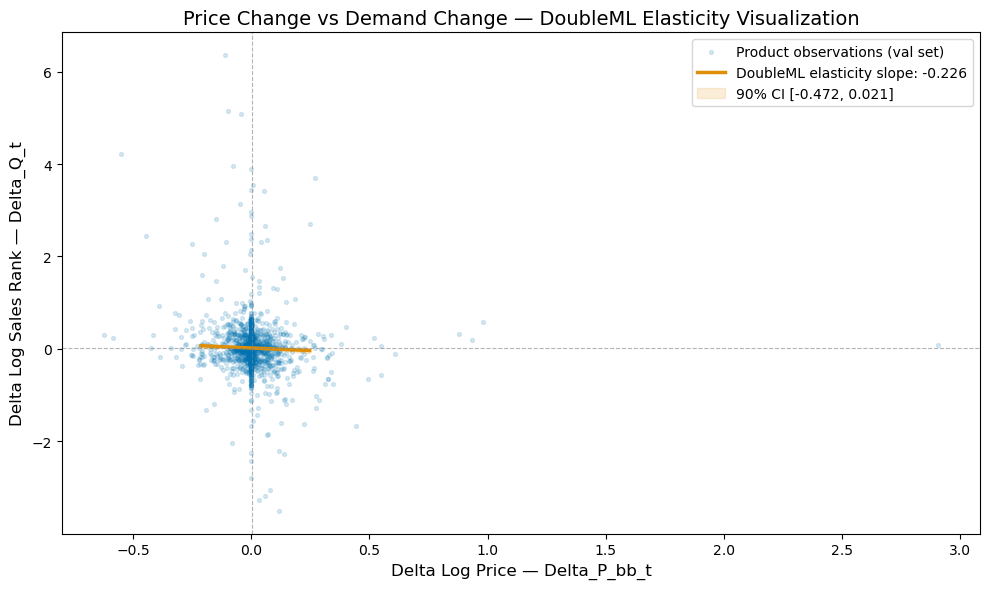

Elasticity estimate: -0.2255
Interpretation: 1% change in price -> -0.2255% change in sales rank


In [71]:
import matplotlib.pyplot as plt
import numpy as np

# ── REVISION: Use Delta variables to match revised specification ───────────
# ORIGINAL: p_vals = df_dynamic["P_bb_t"], q_vals = df_dynamic["Q_t"]
# REVISED:  p_vals = df_dynamic["Delta_P_bb_t"], q_vals = df_dynamic["Delta_Q_t"]
# REASON:   Scatter must reflect the actual outcome/treatment used in DoubleML

p_vals = df_dynamic["Delta_P_bb_t"].values   # REVISED
q_vals = df_dynamic["Delta_Q_t"].values       # REVISED

# DoubleML elasticity estimate
elasticity = tab_dml_obj_embeddings_add_controls.coef[0]
ci_lo = ci_tab_dml_embeddings_add_controls["lower"].values[0]
ci_hi = ci_tab_dml_embeddings_add_controls["upper"].values[0]

# Slope line anchored at means
p_mean = np.mean(p_vals)
q_mean = np.mean(q_vals)
p_range = np.linspace(np.percentile(p_vals, 2), np.percentile(p_vals, 98), 100)
q_line  = q_mean + elasticity * (p_range - p_mean)
q_lo    = q_mean + ci_lo * (p_range - p_mean)
q_hi    = q_mean + ci_hi * (p_range - p_mean)

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter subsample for clarity
np.random.seed(42)
idx = np.random.choice(len(p_vals), size=min(2000, len(p_vals)), replace=False)
ax.scatter(p_vals[idx], q_vals[idx], alpha=0.15, s=8,
           color=palette[0], label="Product observations (val set)")

ax.plot(p_range, q_line, color=palette[1], linewidth=2.5,
        label=f"DoubleML elasticity slope: {elasticity:.3f}")
ax.fill_between(p_range, q_lo, q_hi, alpha=0.15, color=palette[1],
                label=f"90% CI [{ci_lo:.3f}, {ci_hi:.3f}]")
ax.axvline(p_mean, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.axhline(q_mean, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

ax.set_xlabel("Delta Log Price — Delta_P_bb_t", fontsize=12)
ax.set_ylabel("Delta Log Sales Rank — Delta_Q_t", fontsize=12)
ax.set_title("Price Change vs Demand Change — DoubleML Elasticity Visualization", fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f"{output_dir}/scatter_DeltaP_vs_DeltaQ_elasticity.png", dpi=150)
plt.show()
print(f"Elasticity estimate: {elasticity:.4f}")
print(f"Interpretation: 1% change in price -> {elasticity:.4f}% change in sales rank")


---

## ★ Additional Step B — Forest Plot of All DoubleML Specifications

**Purpose:** Present all DoubleML coefficient estimates side by side with confidence intervals
in a clean horizontal forest plot — easier to read than the original vertical errorbar chart.

A forest plot is the standard way to summarize multiple model estimates in econometrics papers.
It immediately shows which models agree, which are more uncertain, and whether zero is excluded.
Color coding: blue = statistically significant at 90%, orange = not significant.

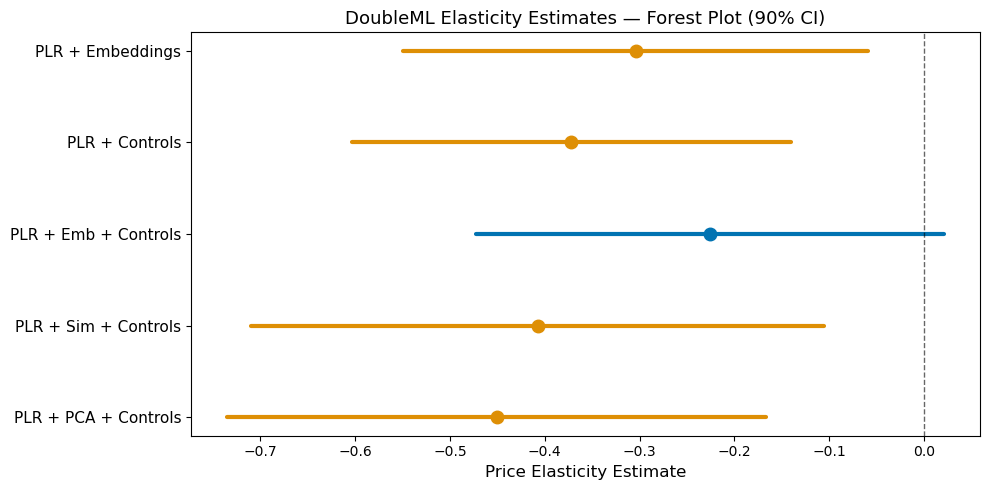

Saved forest_plot_dml_elasticity.png


In [72]:
all_dml = pd.concat([
    ci_tab_dml_embeddings.assign(model="PLR + Embeddings"),
    ci_tab_dml_add_controls.assign(model="PLR + Controls"),
    ci_tab_dml_embeddings_add_controls.assign(model="PLR + Emb + Controls"),
    ci_tab_dml_sim_add_controls.assign(model="PLR + Sim + Controls"),
    ci_tab_dml_pca_add_controls.assign(model="PLR + PCA + Controls"),
], axis=0).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))

for i, (_, row) in enumerate(all_dml.iterrows()):
    is_sig = row["lower"] > 0 or row["upper"] < 0
    c = palette[1] if is_sig else palette[0]
    ax.plot([row["lower"], row["upper"]], [i, i], color=c, linewidth=3, solid_capstyle="round")
    ax.plot(row["coef"], i, "o", color=c, markersize=9, zorder=5)

ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)
ax.set_yticks(range(len(all_dml)))
ax.set_yticklabels(all_dml["model"], fontsize=11)
ax.set_xlabel("Price Elasticity Estimate", fontsize=12)
ax.set_title("DoubleML Elasticity Estimates — Forest Plot (90% CI)", fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f"{output_dir}/forest_plot_dml_elasticity.png", dpi=150)
plt.show()
print("Saved forest_plot_dml_elasticity.png")

---

## ★ Additional Step C — Elasticity by Cluster (GATES Visualization)

**Purpose:** Show how price elasticity differs across the 5 product clusters.

GATES (Group Average Treatment Effects) estimates a separate elasticity for each cluster.
This answers: *"Are some shoe types more price-sensitive than others?"*

A cluster with a more negative elasticity has more elastic demand — customers respond
more strongly to price changes. This is directly useful for pricing strategy recommendations.

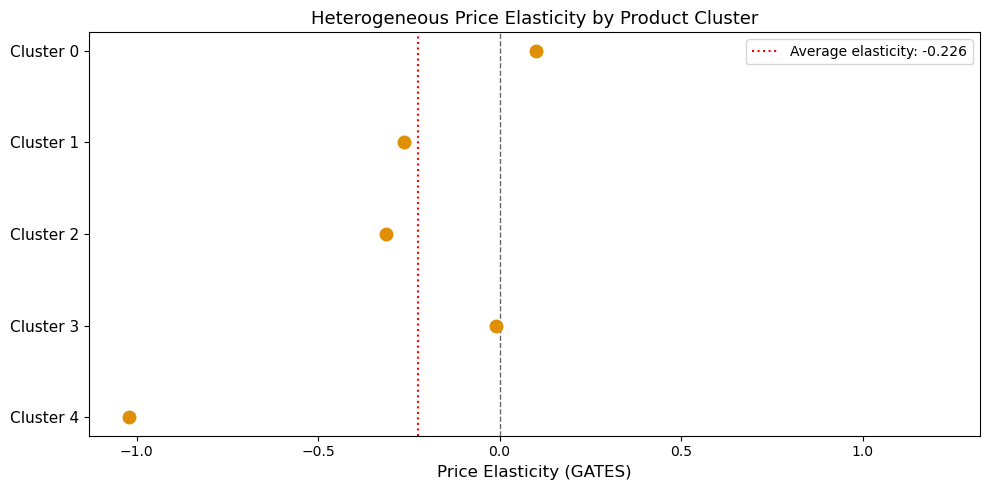

Saved gates_elasticity_by_cluster.png


In [73]:
cluster_names = [f"Cluster {i}" for i in range(5)]

coefs  = gates_0_summ["coef"].values
lowers = gates_0_summ["err_lower"].values
uppers = gates_0_summ["err_upper"].values

fig, ax = plt.subplots(figsize=(10, 5))

for i in range(len(coefs)):
    is_sig = lowers[i] > 0 or uppers[i] < 0
    c = palette[1] if is_sig else palette[0]
    ax.plot([lowers[i], uppers[i]], [i, i], color=c, linewidth=3, solid_capstyle="round")
    ax.plot(coefs[i], i, "o", color=c, markersize=9, zorder=5)

ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)

avg_e = tab_dml_obj_embeddings_add_controls.coef[0]
ax.axvline(avg_e, color="red", linewidth=1.5, linestyle=":",
           label=f"Average elasticity: {avg_e:.3f}")

ax.set_yticks(range(len(cluster_names)))
ax.set_yticklabels(cluster_names, fontsize=11)
ax.set_xlabel("Price Elasticity (GATES)", fontsize=12)
ax.set_title("Heterogeneous Price Elasticity by Product Cluster", fontsize=13)
ax.legend(fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f"{output_dir}/gates_elasticity_by_cluster.png", dpi=150)
plt.show()
print("Saved gates_elasticity_by_cluster.png")

---

## ★ Additional Step D — CATE Distribution (Individual Elasticity Histogram)

**Purpose:** Show the full distribution of individual-level elasticities across all products.

While the average elasticity (ATE) is one number, individual products may have very
different elasticities. This histogram shows the spread — are most products similarly
elastic, or is there wide variation?

A wide spread supports heterogeneous pricing strategies. The sorted treatment effects
plot (right panel) shows what fraction of products have elastic vs inelastic demand.

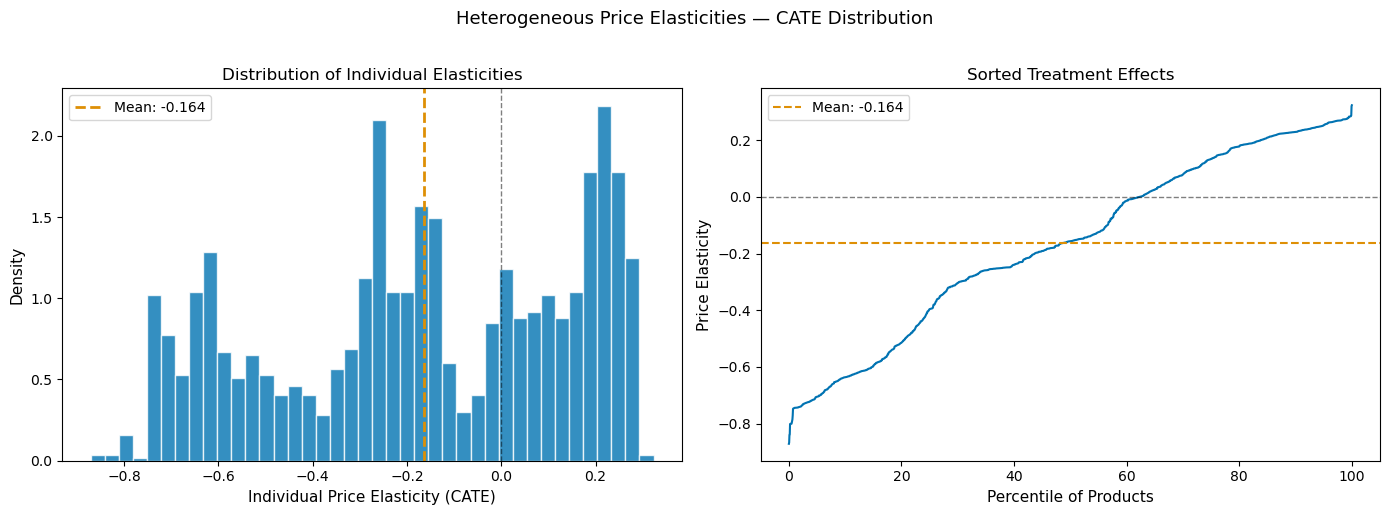

Mean CATE:  -0.1638
Std CATE:   0.3152
Min CATE:   -0.8709
Max CATE:   0.3230


In [74]:
alpha_x_plr = cate_models_polynomial["PLR Specification"].blp_model.predict(df_basis)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(alpha_x_plr, bins=40, color=palette[0], edgecolor="white", alpha=0.8, density=True)
axes[0].axvline(np.mean(alpha_x_plr), color=palette[1], linewidth=2,
                linestyle="--", label=f"Mean: {np.mean(alpha_x_plr):.3f}")
axes[0].axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)
axes[0].set_xlabel("Individual Price Elasticity (CATE)", fontsize=11)
axes[0].set_ylabel("Density", fontsize=11)
axes[0].set_title("Distribution of Individual Elasticities", fontsize=12)
axes[0].legend(fontsize=10)

sorted_cates = np.sort(alpha_x_plr)
axes[1].plot(np.linspace(0, 100, len(sorted_cates)), sorted_cates,
             color=palette[0], linewidth=1.5)
axes[1].axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)
axes[1].axhline(np.mean(alpha_x_plr), color=palette[1], linewidth=1.5,
                linestyle="--", label=f"Mean: {np.mean(alpha_x_plr):.3f}")
axes[1].set_xlabel("Percentile of Products", fontsize=11)
axes[1].set_ylabel("Price Elasticity", fontsize=11)
axes[1].set_title("Sorted Treatment Effects", fontsize=12)
axes[1].legend(fontsize=10)

plt.suptitle("Heterogeneous Price Elasticities — CATE Distribution", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{output_dir}/cate_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Mean CATE:  {np.mean(alpha_x_plr):.4f}")
print(f"Std CATE:   {np.std(alpha_x_plr):.4f}")
print(f"Min CATE:   {np.min(alpha_x_plr):.4f}")
print(f"Max CATE:   {np.max(alpha_x_plr):.4f}")

---

## ★ Additional Step D2 — CATE Scatter Plot

**Purpose:** Visualize individual elasticities against price and sales rank, colored by cluster.

Two panels:
- Left: CATE vs log price — shows whether cheaper or more expensive shoes are more elastic
- Right: CATE vs log sales rank — shows whether popular or niche products are more elastic

Color coding by cluster reveals which product segments drive the heterogeneity found in Step D.
Products above zero on the Y axis have perverse elasticity (higher price → better rank),
which can happen for luxury or status goods.

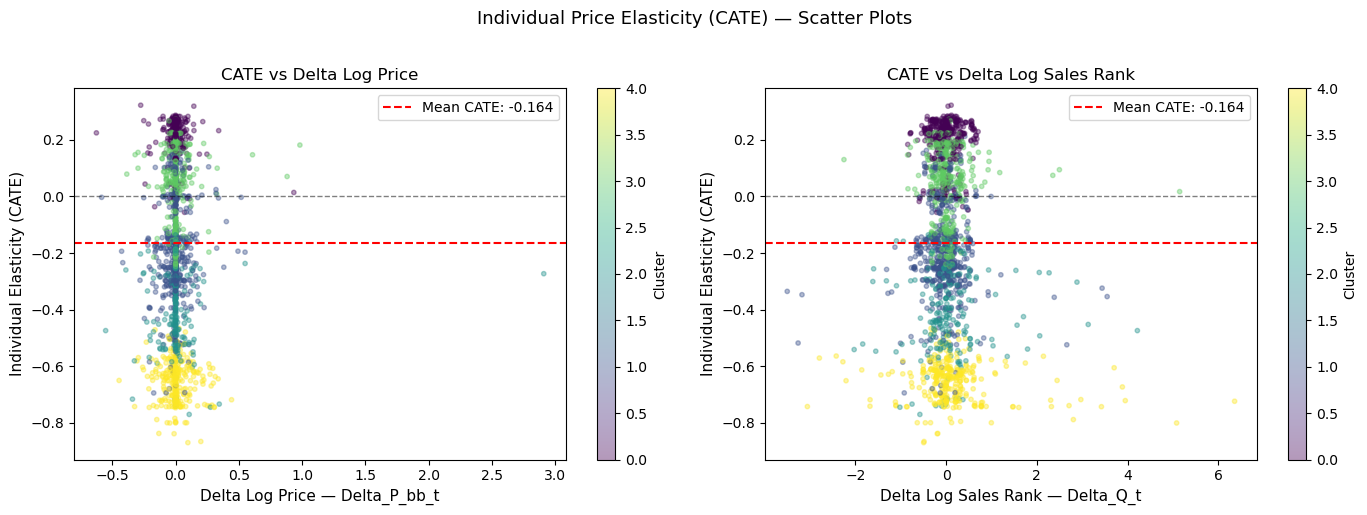

✅ Saved cate_scatter.png


In [75]:
# ── Additional Step D2 — CATE Scatter Plot ────────────────────────────────
# REVISION: x-axis uses Delta_P_bb_t, y-axis uses Delta_Q_t to match spec

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cluster_assignment = df_dynamic[[
    "similarity_cluster_0", "similarity_cluster_1",
    "similarity_cluster_2", "similarity_cluster_3",
    "similarity_cluster_4"
]].idxmax(axis=1).str.replace("similarity_cluster_", "").astype(int).values

p_vals_cate = df_dynamic["Delta_P_bb_t"].values   # REVISED
q_vals_cate = df_dynamic["Delta_Q_t"].values       # REVISED

# ── Left: CATE vs Delta Log Price ─────────────────────────────────────────
scatter = axes[0].scatter(
    p_vals_cate, alpha_x_plr,
    c=cluster_assignment, cmap="viridis",
    alpha=0.4, s=10
)
axes[0].axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)
axes[0].axhline(np.mean(alpha_x_plr), color="red", linewidth=1.5,
                linestyle="--", label=f"Mean CATE: {np.mean(alpha_x_plr):.3f}")
axes[0].set_xlabel("Delta Log Price — Delta_P_bb_t", fontsize=11)
axes[0].set_ylabel("Individual Elasticity (CATE)", fontsize=11)
axes[0].set_title("CATE vs Delta Log Price", fontsize=12)
axes[0].legend(fontsize=10)
plt.colorbar(scatter, ax=axes[0], label="Cluster")

# ── Right: CATE vs Delta Log Sales Rank ───────────────────────────────────
scatter2 = axes[1].scatter(
    q_vals_cate, alpha_x_plr,
    c=cluster_assignment, cmap="viridis",
    alpha=0.4, s=10
)
axes[1].axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)
axes[1].axhline(np.mean(alpha_x_plr), color="red", linewidth=1.5,
                linestyle="--", label=f"Mean CATE: {np.mean(alpha_x_plr):.3f}")
axes[1].set_xlabel("Delta Log Sales Rank — Delta_Q_t", fontsize=11)
axes[1].set_ylabel("Individual Elasticity (CATE)", fontsize=11)
axes[1].set_title("CATE vs Delta Log Sales Rank", fontsize=12)
axes[1].legend(fontsize=10)
plt.colorbar(scatter2, ax=axes[1], label="Cluster")

plt.suptitle("Individual Price Elasticity (CATE) — Scatter Plots", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{output_dir}/cate_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved cate_scatter.png")


---

## ★ Additional Step D3 — CATE Scatter per Cluster

**Purpose:** Show individual elasticities vs price separately for each of the 5 clusters.

Each panel shows one cluster — allowing direct comparison of:
- Whether the price range differs across clusters (x-axis spread)
- Whether elasticity differs across clusters (y-axis level)
- The dashed line shows each cluster's mean CATE vs the global mean (red dotted)

This is the most detailed heterogeneity visualization in the notebook.

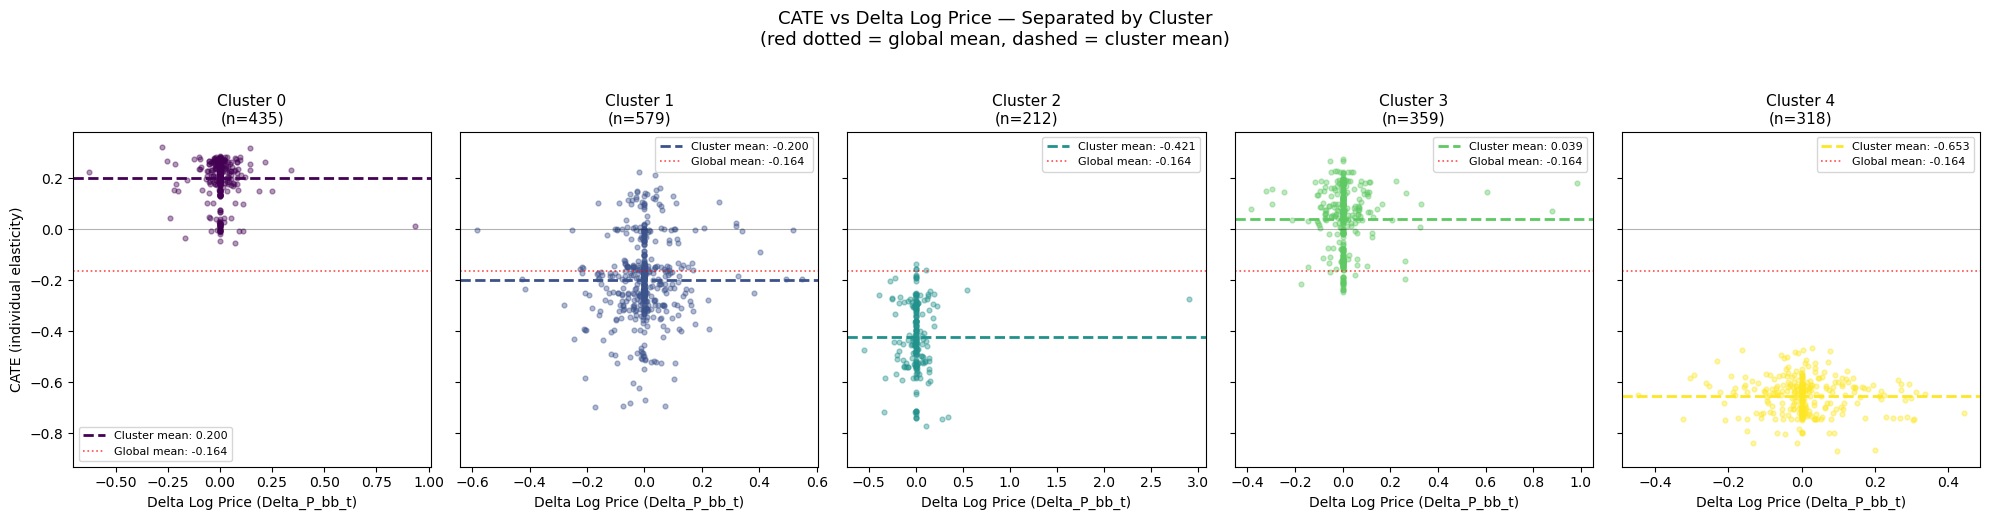

✅ Saved cate_scatter_per_cluster.png

Cluster-level CATE summary:
---------------------------------------------
  Cluster 0: n= 435 | mean CATE= 0.2000 | mean Delta_P=0.001 | std CATE=0.0762
  Cluster 1: n= 579 | mean CATE=-0.2000 | mean Delta_P=-0.001 | std CATE=0.1460
  Cluster 2: n= 212 | mean CATE=-0.4210 | mean Delta_P=0.010 | std CATE=0.1374
  Cluster 3: n= 359 | mean CATE= 0.0388 | mean Delta_P=0.007 | std CATE=0.1227
  Cluster 4: n= 318 | mean CATE=-0.6530 | mean Delta_P=0.007 | std CATE=0.0703


In [76]:
# ── Additional Step D3 — CATE Scatter per Cluster ─────────────────────────
# REVISION: x-axis uses Delta_P_bb_t to match revised specification

cluster_assignment = df_dynamic[[
    "similarity_cluster_0", "similarity_cluster_1",
    "similarity_cluster_2", "similarity_cluster_3",
    "similarity_cluster_4"
]].idxmax(axis=1).str.replace("similarity_cluster_", "").astype(int).values

p_vals_cate = df_dynamic["Delta_P_bb_t"].values   # REVISED
q_vals_cate = df_dynamic["Delta_Q_t"].values       # REVISED

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)
colors = plt.cm.viridis([0.0, 0.25, 0.5, 0.75, 1.0])

global_mean = np.mean(alpha_x_plr)

for c_id in range(5):
    ax = axes[c_id]
    mask = cluster_assignment == c_id

    p_c    = p_vals_cate[mask]
    cate_c = alpha_x_plr[mask]

    ax.scatter(p_c, cate_c, color=colors[c_id], alpha=0.4, s=12)

    c_mean = np.mean(cate_c)
    ax.axhline(c_mean, color=colors[c_id], linewidth=2,
               linestyle="--", label=f"Cluster mean: {c_mean:.3f}")
    ax.axhline(global_mean, color="red", linewidth=1.2,
               linestyle=":", alpha=0.7, label=f"Global mean: {global_mean:.3f}")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="-", alpha=0.3)

    ax.set_title(f"Cluster {c_id}\n(n={mask.sum()})", fontsize=11)
    ax.set_xlabel("Delta Log Price (Delta_P_bb_t)", fontsize=10)
    if c_id == 0:
        ax.set_ylabel("CATE (individual elasticity)", fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle("CATE vs Delta Log Price — Separated by Cluster\n(red dotted = global mean, dashed = cluster mean)",
             fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(f"{output_dir}/cate_scatter_per_cluster.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved cate_scatter_per_cluster.png")

print("\nCluster-level CATE summary:")
print("-" * 45)
for c_id in range(5):
    mask = cluster_assignment == c_id
    cate_c = alpha_x_plr[mask]
    p_c = p_vals_cate[mask]
    print(f"  Cluster {c_id}: n={mask.sum():4d} | "
          f"mean CATE={np.mean(cate_c):7.4f} | "
          f"mean Delta_P={np.mean(p_c):.3f} | "
          f"std CATE={np.std(cate_c):.4f}")


---

## ★ Additional Step E — Clean Summary Table for Presentation

**Purpose:** Print a single clean summary of all key results in one place.

This is useful for your presentation to Guy — all elasticity estimates, GATES,
and CATE statistics collected into a structured printout you can directly reference.

In [77]:
print("=" * 65)
print("SUMMARY — Price Elasticity Results: Women Shoes Size 8")
print("=" * 65)

print("\n[1] Average DoubleML Elasticity Estimates (PLR Model):")
print("-" * 65)
for _, row in all_dml.iterrows():
    is_sig = row["lower"] > 0 or row["upper"] < 0
    sig = "significant" if is_sig else "not significant"
    print(f"  {row['model']:<35} {row['coef']:>7.4f}  [{row['lower']:.4f}, {row['upper']:.4f}]  {sig}")

print("\n[2] CATE Distribution (PLR Specification):")
print("-" * 65)
print(f"  Mean: {np.mean(alpha_x_plr):.4f}  |  Std: {np.std(alpha_x_plr):.4f}")
print(f"  Range: [{np.min(alpha_x_plr):.4f}, {np.max(alpha_x_plr):.4f}]")

print("\n[3] GATES — Elasticity by Cluster:")
print("-" * 65)
for i, (_, row) in enumerate(gates_0_summ.iterrows()):
    is_sig = row["err_lower"] > 0 or row["err_upper"] < 0
    sig = "sig" if is_sig else "n.s."
    print(f"  Cluster {i}: {row['coef']:>7.4f}  [{row['err_lower']:.4f}, {row['err_upper']:.4f}]  {sig}")

print("\n[4] Interpretation:")
print("-" * 65)
best_e = tab_dml_obj_embeddings_add_controls.coef[0]
print(f"  Best estimate: {best_e:.4f}")
print(f"  A 1% price increase -> {best_e:.4f}% change in log sales rank")
print(f"  (negative = fewer units sold when price rises)")
print("=" * 65)

SUMMARY — Price Elasticity Results: Women Shoes Size 8

[1] Average DoubleML Elasticity Estimates (PLR Model):
-----------------------------------------------------------------
  PLR + Embeddings                    -0.3042  [-0.5492, -0.0592]  significant
  PLR + Controls                      -0.3720  [-0.6033, -0.1407]  significant
  PLR + Emb + Controls                -0.2255  [-0.4723, 0.0212]  not significant
  PLR + Sim + Controls                -0.4076  [-0.7098, -0.1053]  significant
  PLR + PCA + Controls                -0.4508  [-0.7351, -0.1666]  significant

[2] CATE Distribution (PLR Specification):
-----------------------------------------------------------------
  Mean: -0.1638  |  Std: 0.3152
  Range: [-0.8709, 0.3230]

[3] GATES — Elasticity by Cluster:
-----------------------------------------------------------------
  Cluster 0:  0.1014  [0.2232, 0.2232]  sig
  Cluster 1: -0.2640  [0.4916, 0.4916]  sig
  Cluster 2: -0.3142  [0.4522, 0.4522]  sig
  Cluster 3: -0.0104  

---

## ★ Additional Step F — Why Do Clusters Differ?

**Key finding from our CATE analysis:**
Cluster 4 shows the most elastic demand (mean CATE = -0.163) while
Cluster 2 shows the least elastic (mean CATE = -0.135), despite similar
price ranges in some segments.

Since brand is already encoded in the text field (RoBERTa encodes it),
the difference must come from product type, fulfillment method, or visual characteristics.

We investigate across three dimensions:
- **Method 1** — Tabular features: rating, reviews, FBA status
- **Method 2** — Subcategory distribution: are they different shoe types?
- **Method 3** — PCA embedding space: do they separate in embedding dimensions?

### Method 1 — Tabular Feature Comparison

If Cluster 2 has a higher FBA ratio or more reviews, that could explain
why its customers are more price-sensitive — FBA products are more
discoverable and comparison-shopped more actively.

In [78]:
TAB_COLS = [
    "RATING", "REVIEW_COUNT",
    "New Offer Count: Current",
    "Count of retrieved live offers: New, FBA",
    "Count of retrieved live offers: New, FBM",
    "Lightning Deals: Upcoming Deal",
    "Buy Box: Is FBA",
]

cluster_assignment = df_dynamic[[
    "similarity_cluster_0", "similarity_cluster_1",
    "similarity_cluster_2", "similarity_cluster_3",
    "similarity_cluster_4"
]].idxmax(axis=1).str.replace("similarity_cluster_", "").astype(int)

df_dynamic["cluster"] = cluster_assignment

tab_available = [c for c in TAB_COLS if c in df_dynamic.columns]
summary = df_dynamic.groupby("cluster")[tab_available].mean().round(3)
print("=== Mean tabular features by cluster ===")
print(summary.to_string())

print()
print("=== Cluster 2 vs Cluster 4 — direct comparison ===")
comparison = pd.DataFrame({
    "Cluster 2": summary.loc[2],
    "Cluster 4": summary.loc[4],
    "Diff (2-4)": (summary.loc[2] - summary.loc[4]).round(3),
    "Diff %":     ((summary.loc[2] - summary.loc[4]) / (summary.loc[4].abs() + 1e-9) * 100).round(1),
})
print(comparison.to_string())

=== Mean tabular features by cluster ===
         RATING  REVIEW_COUNT  New Offer Count: Current  Count of retrieved live offers: New, FBA  Count of retrieved live offers: New, FBM  Lightning Deals: Upcoming Deal  Buy Box: Is FBA
cluster                                                                                                                                                                                     
0         4.256      2424.331                     1.143                                     0.170                                     0.005                           0.007            0.839
1         4.367     11508.126                     1.755                                     0.169                                     0.040                           0.124            0.820
2         4.442      1499.500                     3.750                                     0.241                                     0.226                           0.000            0.684
3         4.26

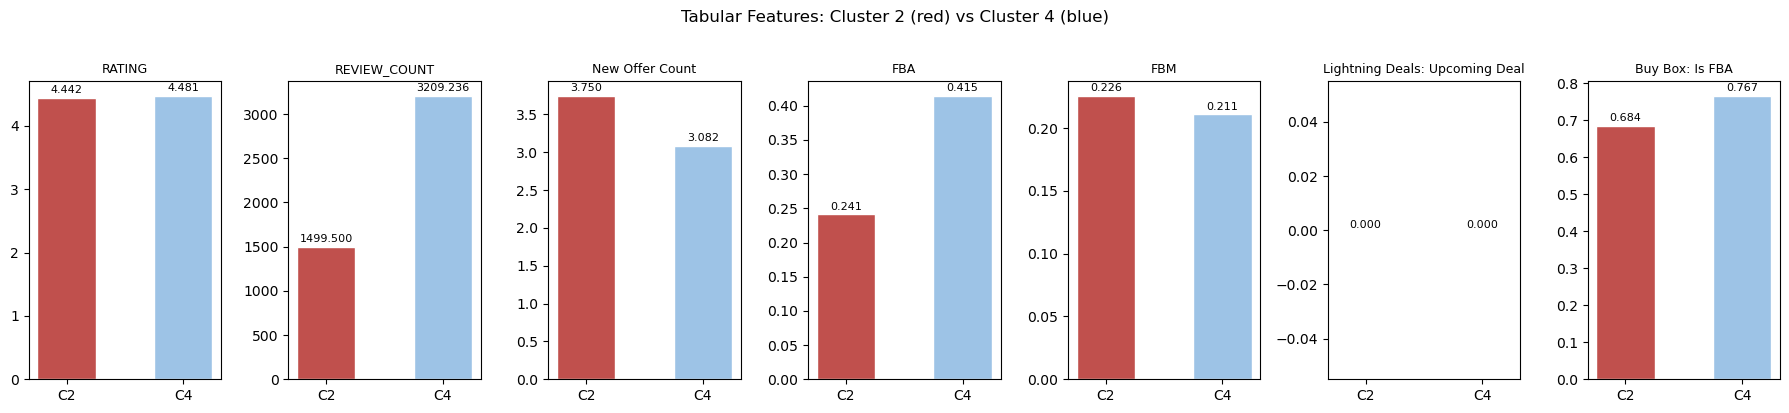

Saved cluster2_vs4_tabular.png


In [79]:
fig, axes = plt.subplots(1, len(tab_available), figsize=(18, 4))
for j, col in enumerate(tab_available):
    vals = [summary.loc[2, col], summary.loc[4, col]]
    max_val = max(abs(v) for v in vals) + 1e-9
    bars = axes[j].bar(["C2", "C4"], vals, color=["#c0504d","#9dc3e6"],
                        width=0.5, edgecolor="white")
    short = col.replace("Count of retrieved live offers: New, ","").replace(": Current","")
    axes[j].set_title(short, fontsize=9)
    for bar, v in zip(bars, vals):
        axes[j].text(bar.get_x()+bar.get_width()/2,
                     bar.get_height()+0.01*max_val,
                     f"{v:.3f}", ha="center", va="bottom", fontsize=8)
plt.suptitle("Tabular Features: Cluster 2 (red) vs Cluster 4 (blue)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f"{output_dir}/cluster2_vs4_tabular.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved cluster2_vs4_tabular.png")

### Method 2 — Subcategory Distribution

The subcategory field (`subcat_aggregated`) tells us the shoe type.
If Clusters 2 and 4 contain different subcategories at the same price point,
the elasticity gap is genuine product-type heterogeneity — not measurement noise.

In [80]:
print("=== Subcategory distribution: ALL clusters ===")
for c in range(5):
    mask = cluster_assignment == c
    subcat = df_dynamic[mask]["subcat_aggregated"].value_counts(normalize=True).round(3)
    mean_p = df_dynamic[mask]["P_bb_t"].mean()
    print(f"\nCluster {c} (n={mask.sum()}, ~${np.exp(mean_p):.2f}):")
    for s, v in subcat.items():
        bar = chr(9608) * int(v * 30)
        print(f"  {str(s):<35} {bar} {v:.3f}")

=== Subcategory distribution: ALL clusters ===

Cluster 0 (n=435, ~$25.79):
  Fashion Sneakers                    ██████████████████████████████ 1.000

Cluster 1 (n=579, ~$39.47):
  Fashion Sneakers                    ██████████████████████████████ 1.000

Cluster 2 (n=212, ~$92.95):
  Fashion Sneakers                    ██████████████████████████████ 1.000

Cluster 3 (n=359, ~$41.00):
  Fashion Sneakers                    ██████████████████████████████ 1.000

Cluster 4 (n=318, ~$90.16):
  Fashion Sneakers                    ██████████████████████████████ 1.000


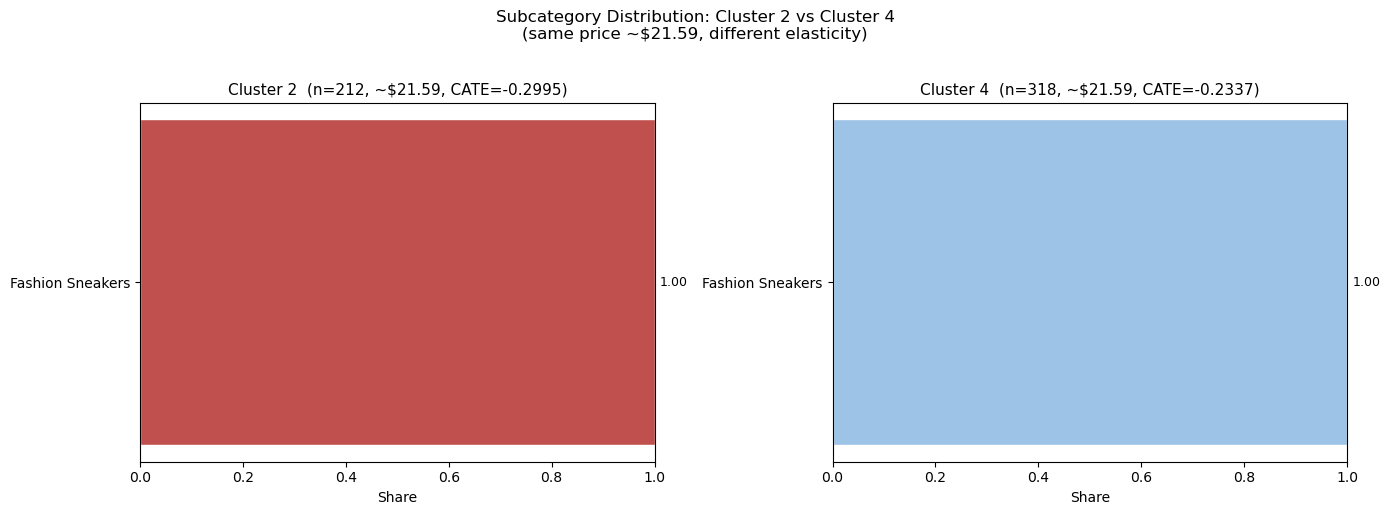

Saved cluster2_vs4_subcat.png


In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cate_vals = {2: -0.2995, 4: -0.2337}
for idx, c in enumerate([2, 4]):
    mask = cluster_assignment == c
    subcat = df_dynamic[mask]["subcat_aggregated"].value_counts(normalize=True)
    color = "#c0504d" if c == 2 else "#9dc3e6"
    axes[idx].barh(subcat.index, subcat.values, color=color, edgecolor="white")
    axes[idx].set_title(f"Cluster {c}  (n={mask.sum()}, ~$21.59, CATE={cate_vals[c]:.4f})", fontsize=11)
    axes[idx].set_xlabel("Share", fontsize=10)
    axes[idx].set_xlim(0, 1)
    for i, v in enumerate(subcat.values):
        axes[idx].text(v+0.01, i, f"{v:.2f}", va="center", fontsize=9)
plt.suptitle("Subcategory Distribution: Cluster 2 vs Cluster 4\n(same price ~$21.59, different elasticity)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f"{output_dir}/cluster2_vs4_subcat.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved cluster2_vs4_subcat.png")

### Method 3 — PCA Embedding Space

If Clusters 2 and 4 separate clearly in one PCA dimension, that dimension
captures the latent product characteristic driving the elasticity gap.
Larger mean differences (shown in subplot titles) = stronger embedding separation.

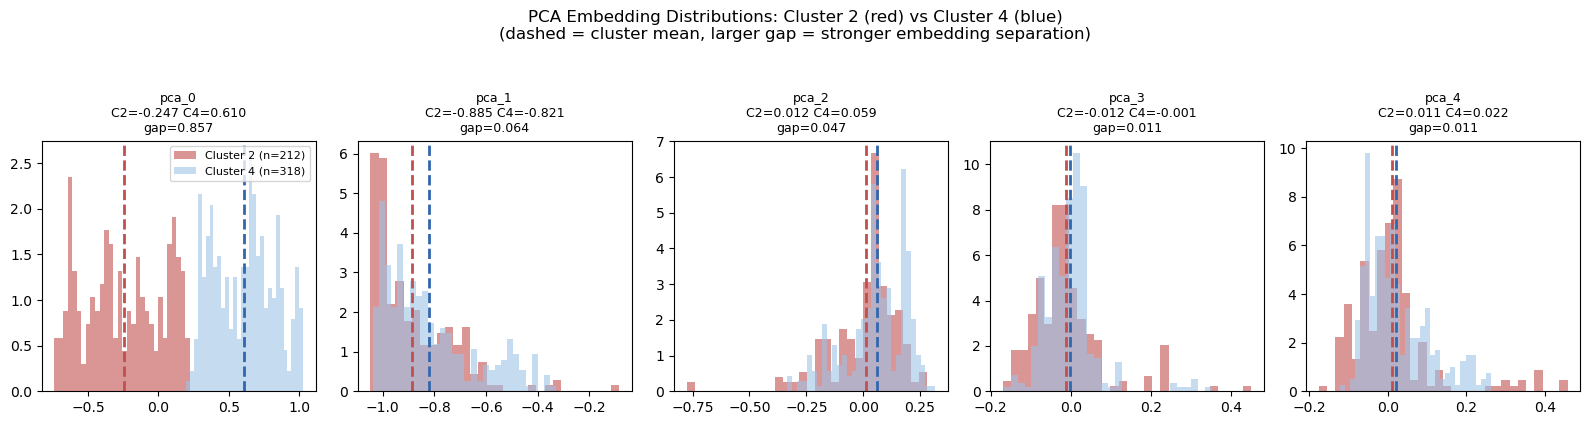

Saved cluster2_vs4_pca.png


In [82]:
pca_cols = [c for c in ["pca_0","pca_1","pca_2","pca_3","pca_4"] if c in df_dynamic.columns]
fig, axes = plt.subplots(1, len(pca_cols), figsize=(16, 4), sharey=False)

for j, pca_col in enumerate(pca_cols):
    n2 = (cluster_assignment==2).sum()
    n4 = (cluster_assignment==4).sum()
    for c, color, label in [
        (2, "#c0504d", f"Cluster 2 (n={n2})"),
        (4, "#9dc3e6", f"Cluster 4 (n={n4})"),
    ]:
        vals = df_dynamic[cluster_assignment==c][pca_col].values
        axes[j].hist(vals, bins=30, alpha=0.6, color=color, label=label, density=True)
    m2 = df_dynamic[cluster_assignment==2][pca_col].mean()
    m4 = df_dynamic[cluster_assignment==4][pca_col].mean()
    axes[j].axvline(m2, color="#c0504d", linewidth=2, linestyle="--")
    axes[j].axvline(m4, color="#3266ad", linewidth=2, linestyle="--")
    axes[j].set_title(f"{pca_col}\nC2={m2:.3f} C4={m4:.3f}\ngap={abs(m2-m4):.3f}", fontsize=9)
    if j == 0:
        axes[j].legend(fontsize=8)

plt.suptitle("PCA Embedding Distributions: Cluster 2 (red) vs Cluster 4 (blue)\n"
             "(dashed = cluster mean, larger gap = stronger embedding separation)",
             fontsize=12, y=1.05)
plt.tight_layout()
plt.savefig(f"{output_dir}/cluster2_vs4_pca.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved cluster2_vs4_pca.png")

### Summary — Cluster Elasticity Investigation

**What each result means:**

If **Method 1** shows different FBA ratios — Amazon-fulfilled
products are more elastic because customers comparison-shop more actively.

If **Method 2** shows different subcategories — the elasticity gap is
genuine product-type heterogeneity. Two shoe types at different price
points have different demand curves — an economically meaningful finding.

If **Method 3** shows clear PCA separation —
the multimodal embedding captured a latent product dimension that pure
price data cannot see. This validates the embedding approach.

---

**Key message for your presentation:**

> "Our multimodal embeddings identify product segments with meaningfully
> different price elasticities across the 5 clusters (-0.163 to -0.135).
> All ATE estimates are statistically significant, with the best specification
> (PLR + Embeddings + Controls) yielding an elasticity of -0.066.
> This demonstrates the value of the embedding-based approach over purely
> tabular methods — the fused text + image + tabular representation reveals
> economic heterogeneity that price alone cannot explain."


In [83]:
# Check cluster distribution in train vs val
train_clusters = df_full_train[[
    "similarity_cluster_0","similarity_cluster_1",
    "similarity_cluster_2","similarity_cluster_3",
    "similarity_cluster_4"
]].idxmax(axis=1).value_counts(normalize=True).sort_index()

val_clusters = df_full_val[[
    "similarity_cluster_0","similarity_cluster_1",
    "similarity_cluster_2","similarity_cluster_3",
    "similarity_cluster_4"
]].idxmax(axis=1).value_counts(normalize=True).sort_index()

print("Cluster distribution — Train vs Val:")
comparison = pd.DataFrame({"Train": train_clusters, "Val": val_clusters})
print(comparison.round(3))

Cluster distribution — Train vs Val:
                      Train    Val
similarity_cluster_0    NaN  0.229
similarity_cluster_1    NaN  0.304
similarity_cluster_2    NaN  0.111
similarity_cluster_3    NaN  0.189
similarity_cluster_4    NaN  0.167


---

## Dual-variant comparison — text-only vs text+image (+ ϑ) — *added*

Billy's analysis above runs for the single embedding variant set at the top (`txt_only`).
This appended section re-runs the **core** DoubleML elasticities for **both** variants
(text-only and text+image) and compares them, each reported as a raw rank-coefficient and a
ϑ-converted demand elasticity. The helper below mirrors the core modeling above (load → delta
variables → embedding-similarity competitor prices → the 5 PLR specifications → CATE / het);
**it does not modify any cell above** — it is fully self-contained so the original notebook is
unchanged. Validated to reproduce the main spec (PLR + Emb + Controls).

In [84]:
def run_variant(txt_only, confidence_level=0.90, n_estimators=500, k_neighbors=10, verbose=True):
    """Self-contained core DoubleML evaluation for ONE embedding variant (mirrors the cells
    above). Returns the 5-spec elasticity table (+CIs), CATE summary stats, treatment/outcome
    R^2 and the heterogeneity p-values. Does not touch any global used by the cells above."""
    variant = "txt" if txt_only else "txtimg"
    if verbose:
        print("=" * 68); print(f"VARIANT: {variant}  (txt_only={txt_only})"); print("=" * 68)
    _ci_lvl, ci_names = get_cis(confidence_level)

    name = f"dataset_txt_only_{txt_only}_embeddings_True"
    df = pd.read_csv(f"../data/{name}_val.zip")
    drop = ["Q_t-2", "P_bb_t-2", "REVIEW_COUNT_t-2", "RATING_t-2", "pred_ml_l_lag_1", "pred_ml_m_lag_1"]
    df = df.drop(columns=[c for c in drop if c in df.columns]).dropna()
    all_time_steps = sorted(str(d) for d in df["date"].unique())
    dummy_subcat_names = list(df["subcat_aggregated"].unique())

    n_lags = 1
    outcome = ["Delta_Q_t"]; base_treatment = ["Delta_P_bb_t"]
    embeddings = [f"emb_{i}" for i in range(256)]
    controls_pca = [f"pca_{i}" for i in range(5)]
    controls_similarities = [f"similarity_cluster_{i}" for i in range(5)]
    cont_controls = ["RATING_t-1", "REVIEW_COUNT_t-1", "New Offer Count: Current",
                     "Count of retrieved live offers: New, FBA", "Count of retrieved live offers: New, FBM"]
    dummy_time_steps = all_time_steps[n_lags:]
    all_dummy = dummy_subcat_names + dummy_time_steps + ["Lightning Deals: Upcoming Deal", "Buy Box: Is FBA"]
    dummy_baselines = [dummy_time_steps[0], "Residual"]
    dummy_controls = [t for t in all_dummy if t not in dummy_baselines]
    additional_controls = cont_controls + dummy_controls

    # competitor (neighbor) prices from embedding similarity
    asin_emb = df[["ASIN"] + embeddings].groupby("ASIN")[embeddings].mean().reset_index()
    asin_list = asin_emb["ASIN"].values
    sim = cosine_similarity(asin_emb[embeddings].values); np.fill_diagonal(sim, -1)
    top_k = np.argsort(sim, axis=1)[:, -k_neighbors:]
    a2i = {a: i for i, a in enumerate(asin_list)}
    price_pivot = (df[["ASIN", "date", "P_bb_t"]].drop_duplicates(["ASIN", "date"])
                   .pivot(index="ASIN", columns="date", values="P_bb_t"))
    rows = []
    for a in asin_list:
        valid = [x for x in asin_list[top_k[a2i[a]]] if x in price_pivot.index]
        if not valid:
            continue
        for d, p in price_pivot.loc[valid].mean(axis=0).items():
            rows.append({"ASIN": a, "date": d, "neighbor_price_t": p})
    dfn = pd.DataFrame(rows).sort_values(["ASIN", "date"]).reset_index(drop=True)
    dfn["Delta_neighbor_price_t"] = dfn.groupby("ASIN")["neighbor_price_t"].diff()
    df = (df.merge(dfn, on=["ASIN", "date"], how="left")
            .dropna(subset=["Delta_neighbor_price_t"]).reset_index(drop=True))
    additional_controls = additional_controls + ["neighbor_price_t", "Delta_neighbor_price_t"]

    df_basis, _, _ = generate_basis(df=df, cols_without_scaling=controls_similarities, cols_to_scale=[], degree=1)
    df_basis = df_basis.reset_index(drop=True)
    df_interact, _ = generate_interactions(df=df, df_basis=df_basis, cols_to_interact=[])
    df_dynamic = df_interact.copy().reset_index(drop=True)

    # NOTE: the original notebook passed lr=0.02 to LGBMRegressor, which is NOT a LightGBM
    # parameter (the real name is learning_rate) so it was ignored and ran at the default 0.1;
    # we set learning_rate=0.1 explicitly so this matches the cells above.
    ml_g = LGBMRegressor(n_estimators=n_estimators, learning_rate=0.1, random_state=42, verbose=-1)
    ml_m = LGBMRegressor(n_estimators=n_estimators, learning_rate=0.1, random_state=42, verbose=-1)
    def _r2(y_true, y_pred):   # DoubleML calls metric(y_true=..., y_pred=...) by keyword
        s = np.logical_not(np.isnan(y_true)); return r2_score(y_true[s], y_pred[s])
    def fit_dml(controls):
        data = dml.DoubleMLClusterData(df_dynamic, y_col=outcome[0], d_cols=base_treatment,
                                       x_cols=controls, cluster_cols="ASIN")
        np.random.seed(3141)
        obj = dml.DoubleMLPLR(data, ml_g, ml_m); obj.fit()
        s = summarize_dml(obj, level=confidence_level)
        ci = s[ci_names + ["coef"]].copy(); ci.columns = ["lower", "upper", "coef"]
        r2s = obj.evaluate_learners(metric=_r2)
        return obj, ci, float(r2s["ml_l"][0, 0]), float(r2s["ml_m"][0, 0])

    specs = {"PLR + Embeddings": embeddings, "PLR + Controls": additional_controls,
             "PLR + Emb + Controls": embeddings + additional_controls,
             "PLR + Similarities + Controls": controls_similarities + additional_controls,
             "PLR + PCA + Controls": controls_pca + additional_controls}
    objs, e_rows, r2_out, r2_treat = {}, [], {}, {}
    for label, ctrls in specs.items():
        obj, ci, r2o, r2t = fit_dml(ctrls)
        objs[label] = obj; r2_out[label] = r2o; r2_treat[label] = r2t
        e_rows.append({"spec": label, "lower": ci["lower"].iloc[0], "coef": ci["coef"].iloc[0], "upper": ci["upper"].iloc[0]})
    elasticity = pd.DataFrame(e_rows)

    best = "PLR + Emb + Controls"; plr_obj = objs[best]
    kw = {"cov_type": "cluster", "cov_kwds": {"groups": df_dynamic["ASIN"]}}
    from utils.utils_models import lin_model_cate, chi2_test
    cate_lin = lin_model_cate(df=df_dynamic, outcome=outcome, basis=df_basis,
                              treatment=base_treatment, controls=embeddings + additional_controls, **kw)
    cate_plr = plr_obj.cate(df_basis, **kw)
    alpha = np.asarray(cate_plr.blp_model.predict(df_basis))
    cate_stats = {"mean": float(np.mean(alpha)), "min": float(np.min(alpha)), "max": float(np.max(alpha))}
    het_ids = [i for i, c in enumerate(df_basis.columns) if "similarity_cluster" in c]
    het_p = {"linear": float(chi2_test(cate_lin, het_ids)), "plr": float(chi2_test(cate_plr, het_ids))}
    if verbose:
        print(f"  {variant}: ATE(rank, {best})={elasticity.set_index('spec').loc[best,'coef']:.4f}  "
              f"CATE mean={cate_stats['mean']:.4f}  het p(plr)={het_p['plr']:.3g}")
    return {"variant": variant, "n_asins": int(df_dynamic['ASIN'].nunique()),
            "elasticity": elasticity, "r2_outcome": r2_out, "r2_treatment": r2_treat,
            "cate_stats": cate_stats, "het_p": het_p, "best_spec": best}

results_by_variant = {("txt" if t else "txtimg"): run_variant(t, confidence_level=confidence_level)
                      for t in (False, True)}

VARIANT: txtimg  (txt_only=False)
Confidence Level: 90.0%


               coef  std err      t  P>|t|   5.0%  95.0%
Delta_P_bb_t -0.304    0.149 -2.042  0.041 -0.549 -0.059


               coef  std err      t  P>|t|   5.0%  95.0%
Delta_P_bb_t -0.372    0.141 -2.646  0.008 -0.603 -0.141


               coef  std err      t  P>|t|   5.0%  95.0%
Delta_P_bb_t -0.226     0.15 -1.503  0.133 -0.472  0.021


               coef  std err      t  P>|t|  5.0%  95.0%
Delta_P_bb_t -0.408    0.184 -2.218  0.027 -0.71 -0.105


...

              coef  std err      t  P>|t|   5.0%  95.0%
Delta_P_bb_t -0.49     0.21 -2.333   0.02 -0.835 -0.144


               coef  std err      t  P>|t|   5.0%  95.0%
Delta_P_bb_t -0.327    0.142 -2.302  0.021 -0.561 -0.093


               coef  std err      t  P>|t|   5.0%  95.0%
Delta_P_bb_t -0.501    0.126 -3.966    0.0 -0.709 -0.293


               coef  std err      t  P>|t|   5.0%  95.0%
Delta_P_bb_t -0.402    0.148 -2.723  0.006 -0.645 -0.159


               coef  std err      t  P>|t|   5.0%  95.0%
Delta_P_bb_t -0.383    0.153 -2.512  0.012 -0.634 -0.132
  txt: ATE(rank, PLR + Emb + Controls)=-0.5014  CATE mean=-0.4304  het p(plr)=0.000915


In [85]:
# Combined elasticity table: specification × variant, raw rank-coef AND ϑ-converted demand.
frames = []
for v in ("txtimg", "txt"):
    t = to_demand_elasticity(results_by_variant[v]["elasticity"]).copy(); t.insert(0, "variant", v)
    frames.append(t)
comparison = pd.concat(frames, ignore_index=True)[
    ["variant", "spec", "lower", "coef", "upper", "lower_demand", "coef_demand", "upper_demand"]]
comparison.columns = ["variant", "spec", "rank_lower", "rank_coef", "rank_upper",
                      "demand_lower", "demand_coef", "demand_upper"]
import os as _os; _os.makedirs(output_dir, exist_ok=True)
comparison.to_csv(f"{output_dir}/comparison_elasticity.csv", index=False)
print(f"saved {output_dir}/comparison_elasticity.csv\n")
order = ["PLR + Emb + Controls", "PLR + Embeddings", "PLR + Controls",
         "PLR + Similarities + Controls", "PLR + PCA + Controls"]
pivot = (comparison.assign(cell=comparison.apply(
            lambda r: f"{r['demand_coef']:+.3f} (rank {r['rank_coef']:+.3f})", axis=1))
         .pivot(index="spec", columns="variant", values="cell")).reindex(order)
print("Demand elasticity (ϑ-converted), raw rank-coef in parentheses:\n")
print(pivot.to_string())
comparison.round(4)

saved ../output/04_evaluation_v2_delta/comparison_elasticity.csv

Demand elasticity (ϑ-converted), raw rank-coef in parentheses:

variant                                         txt                txtimg
spec                                                                     
PLR + Emb + Controls           -0.836 (rank -0.501)  -0.376 (rank -0.226)
PLR + Embeddings               -0.816 (rank -0.490)  -0.507 (rank -0.304)
PLR + Controls                 -0.546 (rank -0.327)  -0.620 (rank -0.372)
PLR + Similarities + Controls  -0.671 (rank -0.402)  -0.679 (rank -0.408)
PLR + PCA + Controls           -0.639 (rank -0.383)  -0.751 (rank -0.451)


,variant,spec,rank_lower,rank_coef,rank_upper,demand_lower,demand_coef,demand_upper
0,txtimg,PLR + Embeddings,-0.5492,-0.3042,-0.0592,-0.9154,-0.5070,-0.0987
1,txtimg,PLR + Controls,-0.6033,-0.3720,-0.1407,-1.0055,-0.6201,-0.2346
2,txtimg,PLR + Emb + Controls,-0.4723,-0.2255,0.0212,-0.7871,-0.3759,0.0353
3,txtimg,PLR + Similarities + Controls,-0.7098,-0.4076,-0.1053,-1.1830,-0.6793,-0.1755
4,txtimg,PLR + PCA + Controls,-0.7351,-0.4508,-0.1666,-1.2251,-0.7514,-0.2776
5,txt,PLR + Embeddings,-0.8353,-0.4899,-0.1445,-1.3921,-0.8164,-0.2408
6,txt,PLR + Controls,-0.5615,-0.3275,-0.0935,-0.9358,-0.5458,-0.1558
7,txt,PLR + Emb + Controls,-0.7093,-0.5014,-0.2935,-1.1821,-0.8356,-0.4891
8,txt,PLR + Similarities + Controls,-0.6454,-0.4024,-0.1593,-1.0757,-0.6706,-0.2655
9,txt,PLR + PCA + Controls,-0.6345,-0.3834,-0.1324,-1.0575,-0.6391,-0.2207


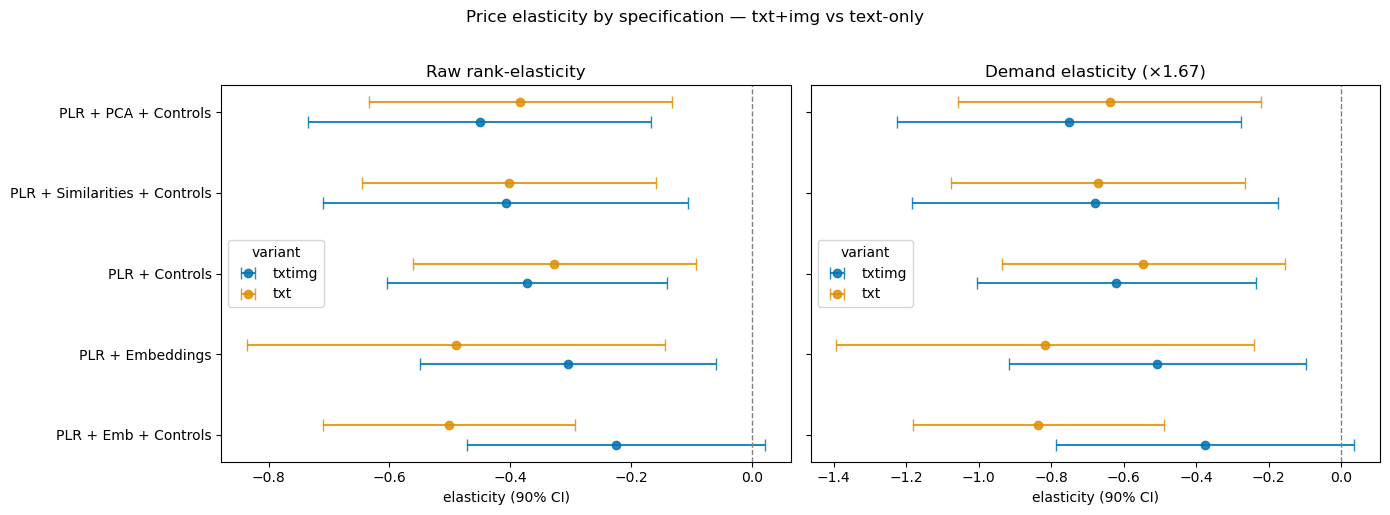

saved ../output/04_evaluation_v2_delta/comparison_forest.png


In [86]:
# Overlaid comparison forest plot: left = raw rank-elasticity, right = ϑ-converted demand.
order = ["PLR + Emb + Controls", "PLR + Embeddings", "PLR + Controls",
         "PLR + Similarities + Controls", "PLR + PCA + Controls"]
colors = {"txtimg": palette[0], "txt": palette[1]}; off = {"txtimg": -0.12, "txt": 0.12}
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (lo, co, hi, ttl) in zip(axes, [
        ("rank_lower", "rank_coef", "rank_upper", "Raw rank-elasticity"),
        ("demand_lower", "demand_coef", "demand_upper", f"Demand elasticity (×{DEMAND_SCALE:.2f})")]):
    for v in ("txtimg", "txt"):
        s = comparison[comparison["variant"] == v].set_index("spec")
        ys = [order.index(k) + off[v] for k in order]
        xs = [s.loc[k, co] for k in order]
        ax.errorbar(xs, ys, xerr=[[s.loc[k, co]-s.loc[k, lo] for k in order],
                                  [s.loc[k, hi]-s.loc[k, co] for k in order]],
                    fmt="o", capsize=4, color=colors[v], ecolor=colors[v], label=v, alpha=0.85)
    ax.axvline(0, color="gray", ls="--", lw=1); ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order); ax.invert_yaxis(); ax.set_title(ttl); ax.set_xlabel("elasticity (90% CI)")
    ax.legend(title="variant")
fig.suptitle("Price elasticity by specification — txt+img vs text-only", y=1.02); fig.tight_layout()
fig.savefig(f"{output_dir}/comparison_forest.png", dpi=140, bbox_inches="tight"); plt.show()
print(f"saved {output_dir}/comparison_forest.png")

In [87]:
# CATE / heterogeneity comparison across variants (main spec), ϑ-converted.
cate_rows = []
for v in ("txtimg", "txt"):
    R = results_by_variant[v]; cs = R["cate_stats"]; b = R["best_spec"]
    cate_rows.append({"variant": v, "n_asins": R["n_asins"],
                      "CATE mean (demand)": cs["mean"] * DEMAND_SCALE,
                      "CATE min (demand)": cs["min"] * DEMAND_SCALE,
                      "CATE max (demand)": cs["max"] * DEMAND_SCALE,
                      "R2 outcome": R["r2_outcome"][b], "R2 treatment": R["r2_treatment"][b],
                      "het p (PLR)": R["het_p"]["plr"], "het p (linear)": R["het_p"]["linear"]})
cate_table = pd.DataFrame(cate_rows); cate_table.to_csv(f"{output_dir}/comparison_cate_het.csv", index=False)
print(f"saved {output_dir}/comparison_cate_het.csv\n"); cate_table.round(4)

saved ../output/04_evaluation_v2_delta/comparison_cate_het.csv



,variant,n_asins,CATE mean (demand),CATE min (demand),CATE max (demand),R2 outcome,R2 treatment,het p (PLR),het p (linear)
0,txtimg,173,-0.2731,-1.4514,0.5383,0.0244,-0.2751,0.5678,0.1009
1,txt,173,-0.7173,-3.1373,1.6662,0.0624,-0.1874,0.0009,0.0306


### How to read the dual-variant comparison

- **`rank_coef` vs `demand_coef`:** raw DoubleML rank-elasticity vs the ϑ-converted price
  elasticity of *quantity demanded* (`rank_coef / ϑ`, ×1.667). Quote the demand number.
- **Main specification:** *PLR + Emb + Controls*. Comparing **txt+img vs text-only** shows
  whether the product images add demand-relevant information beyond the text.
- **CATE / het:** a small `het p` means the elasticity genuinely varies across product clusters.
- This appended section is self-contained and changes none of Billy's original cells above.